# Testing the model

## Figures

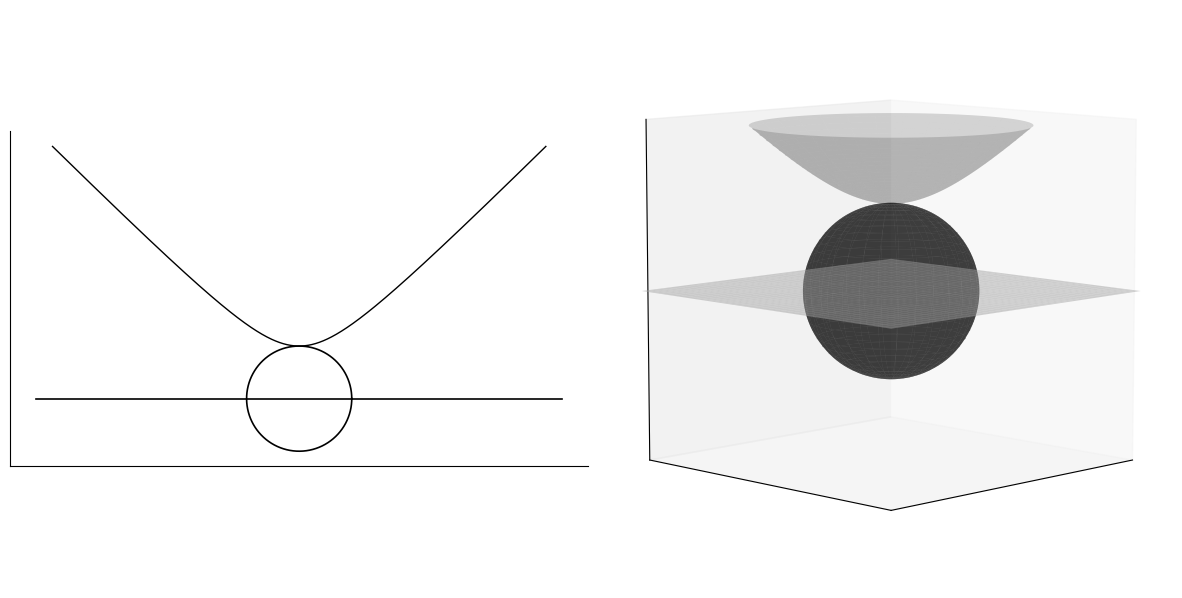

In [292]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# Parameters
# ======================
R = 1.0
H = 2.250
fig = plt.figure(figsize=(15,8))
plt.subplots_adjust(wspace=0.01)
gs = fig.add_gridspec(1, 2, width_ratios=[1,1])

# ======================
# LEFT: R^2
# ======================
ax1 = fig.add_subplot(gs[0,0])

# R^1
x = np.linspace(-5.0, 5.0, 400)
ax1.plot(x, np.zeros_like(x), color='black', linewidth=1.2)

# S^1
theta = np.linspace(0, 2*np.pi, 400)
ax1.plot(R*np.cos(theta), R*np.sin(theta), color='black', linewidth=1.2)

# H^1
u = np.linspace(-H, H, 400)
ax1.plot(R*np.sinh(u), R*np.cosh(u), color='black', linewidth=1.0)

ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_aspect('equal')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(True)
ax1.spines['bottom'].set_visible(True)
ax1.set_anchor('C')
#ax1.axis('off')


# ======================
# RIGHT: R^3
# ======================
ax2 = fig.add_subplot(gs[0,1], projection='3d')

# Plane R^2
grid = np.linspace(-2.0, 2.0, 40)
X, Y = np.meshgrid(grid, grid)
Z = np.zeros_like(X)
ax2.plot_surface(X, Y, Z, color='lightgray', alpha=0.5, linewidth=0)

# Sphere S^2
u = np.linspace(0, 2*np.pi, 60)
v = np.linspace(0, np.pi, 60)
Xs = R * np.outer(np.cos(u), np.sin(v))
Ys = R * np.outer(np.sin(u), np.sin(v))
Zs = R * np.outer(np.ones_like(u), np.cos(v))
ax2.plot_surface(Xs, Ys, Zs, color='black', alpha=0.5, linewidth=0)

# Hyperboloid H^2
u = np.linspace(0, 2*np.pi, 60)
r = np.linspace(0, 1.25, 60)
U, Rg = np.meshgrid(u, r)

Xh = np.sinh(Rg) * np.cos(U)
Yh = np.sinh(Rg) * np.sin(U)
Zh = np.cosh(Rg)

ax2.plot_surface(Xh, Yh, Zh, color='black', alpha=0.15, linewidth=0)

# Clean 3D appearance
ax2.set_box_aspect([1,1,1])
ax2.view_init(elev=8, azim=45)
lim = 1.95
ax2.set_xlim(-lim, lim)
ax2.set_ylim(-lim, lim)
ax2.set_zlim(-lim, lim)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_zticks([])
ax2.dist = 8
ax2.set_anchor('C')

plt.show()

## Experiment 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import pandas as pd
from itertools import combinations

def phi(x, center, sigma):
    r2 = np.sum((x-center)**2,axis=-1)
    return np.exp(-r2/(2*sigma**2))
def xi(x, centers, weights, sigma):
    val = 1
    for c,xii in zip(centers,weights):
        val += (xii-1)*phi(x,c,sigma)
    return val

def curve_length(points, centers, weights, sigma, lam_curv=5.0, lam_speed=1.0):
    p = points[:-1]
    q = points[1:]
    mid = 0.5*(p+q)
    ds = np.linalg.norm(q-p,axis=1)
    xi_vals = xi(mid,centers,weights,sigma)
    length = np.sum(xi_vals*ds)
    accel = np.diff(points,2,axis=0)
    curvature_penalty = np.sum(np.linalg.norm(accel,axis=1)**2)
    speed = np.linalg.norm(np.diff(points,axis=0),axis=1)
    speed_penalty = np.sum((speed-np.mean(speed))**2)
    return length + lam_curv*curvature_penalty + lam_speed*speed_penalty


def geodesic_distance(x1,x2,centers,weights,sigma, n_points=40,  lam_curv=20.0, lam_speed=5.0):
    t = np.linspace(0,1,n_points)
    curve = np.outer(1-t,x1)+np.outer(t,x2)
    x0 = curve[1:-1].flatten()
    def objective(v):
        pts = np.vstack([x1,v.reshape(-1,2),x2])
        return curve_length(pts,centers,weights,sigma, lam_curv,lam_speed)
    res = minimize(objective,x0,method="L-BFGS-B")
    pts = np.vstack([x1,res.x.reshape(-1,2),x2])
    dist = curve_length(pts,centers,weights,sigma,
                        lam_curv,lam_speed)
    return dist,pts


def theoretical_distance(x1,x2,centers,weights,sigma):
    h = np.linalg.norm(x2-x1)
    xi1 = xi(x1,centers,weights,sigma)
    xi2 = xi(x2,centers,weights,sigma)
    return 0.5*(xi1+xi2)*h

def line_geodesic_distance(path, x1, x2, relative=False, n_samples=250):
    t = np.linspace(0,1,n_samples)
    line = np.outer(1-t,x1) + np.outer(t,x2)
    d1 = np.max([np.min(np.linalg.norm(p-line,axis=1)) for p in path])
    d2 = np.max([np.min(np.linalg.norm(p-path,axis=1)) for p in line])
    d = max(d1,d2)
    if relative:
        d /= np.linalg.norm(x2-x1)
    return d

# Experiment
def run_experiment(points,weights,sigma):
    centers = points
    results = []
    paths = {}
    for i,j in combinations(range(len(points)),2):
        x1 = points[i]
        x2 = points[j]
        d_euclid = np.linalg.norm(x2-x1)
        d_geo,path = geodesic_distance(x1,x2,centers,weights,sigma)
        d_theory = theoretical_distance(x1,x2,centers,weights,sigma)
        err = abs(d_geo-d_theory)/d_geo
        curve_dev = line_geodesic_distance(path,x1,x2)
        results.append({"pair":f"{i+1}-{j+1}","euclidean":d_euclid,"geodesic":d_geo,"approximation":d_theory,"relative_error":err,"curve_deviation":curve_dev})
        paths[(i,j)] = path
    df = pd.DataFrame(results)
    return df,paths

def plot_geometry(points, weights, sigma, paths, fsize=(10,6)):
    offset = 0.5
    xmin, xmax = points[:,0].min()-offset, points[:,0].max()+offset
    ymin, ymax = points[:,1].min()-offset, points[:,1].max()+offset

    xx = np.linspace(xmin, xmax, 200)
    yy = np.linspace(ymin, ymax, 200)
    X, Y = np.meshgrid(xx, yy)
    grid = np.stack([X, Y], axis=-1)
    Xi = xi(grid, points, weights, sigma)
    plt.figure(figsize=fsize)
    levels = np.linspace(1/3, 5/3, 40)
    contour = plt.contourf(X, Y, Xi, levels=levels, cmap="coolwarm", vmin=1/3, vmax=5/3)
    cbar = plt.colorbar(contour)
    cbar.set_label(r"$\xi(z)$")
    cbar.set_ticks(np.linspace(1/3, 5/3, 13))
    first_line = True
    first_geo = True
    xi_points = xi(points, points, weights, sigma)
    for (i, j), path in paths.items():
        p1 = points[i]
        p2 = points[j]
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'w--', alpha=0.7, label="Euclidean segment" if first_line else None)
        plt.plot(path[:,0], path[:,1], 'k', label="Geodesic" if first_geo else None)
        first_line = False
        first_geo = False
    plt.scatter(points[:,0], points[:,1], c=xi_points, cmap="coolwarm",zorder=10, vmin=1/3, vmax=5/3, edgecolors="black", label="Points")
    for i, (x, y) in enumerate(points):
        plt.text(x + 0.02, y + 0.02, rf"$z^{{({i+1})}}$", color="black", fontsize=11, weight='bold')
    plt.legend(fontsize=9, frameon=True)
    plt.rcParams.update({"font.size": 9, "legend.fontsize": 9})
    plt.show()



In [2]:
def plot_numeric_scales_normalized(df, fsize=(10,4)):
    import matplotlib.pyplot as plt
    import numpy as np

    fig, ax = plt.subplots(figsize=fsize)

    y_pos = {
        "euclidean": 4,
        "geodesic": 3,
        "approximation": 2,
        "relative_error": 1,
        "curve_deviation": 0
    }

    labels = {
        "euclidean": "Euclidean",
        "geodesic": "Geodesic",
        "approximation": "Approximation",
        "relative_error": "Relative error",
        "curve_deviation": "Curve deviation"
    }

    ranges = {
        "euclidean": (0, df["euclidean"].max()*1.1),
        "geodesic": (0, df["geodesic"].max()*1.1),
        "approximation": (0, df["approximation"].max()*1.1),
        "relative_error": (1e-16, 1),
        "curve_deviation": (1e-16, 1)
    }

    cmap = plt.cm.coolwarm
    n = len(df)
    colors = [cmap(i/(n-1 if n>1 else 1)) for i in range(n)]

    def normalize(x, xmin, xmax):
        return (x - xmin) / (xmax - xmin)

    for key, y in y_pos.items():
        xmin, xmax = ranges[key]

        ax.hlines(y, 0, 1, color='black', linewidth=1)

        if key in ["relative_error", "curve_deviation"]:
            ticks = [1e-16, 1e-8, 1e-4, 1e-2, 1e-1,1.0]
        else:
            ticks = np.linspace(xmin, xmax, 5)

        for t in ticks:
            if key in ["relative_error", "curve_deviation"]:
                xt = (np.log10(t) - np.log10(xmin)) / (np.log10(xmax) - np.log10(xmin))
                label = f"$10^{{{int(np.log10(t))}}}$"
            else:
                xt = normalize(t, xmin, xmax)
                label = f"{t:.2f}"
            ax.text(xt, y-0.25, label, ha='center', fontsize=8)
        ax.text(1.05, y, labels[key], va='center')
    for i, (_, row) in enumerate(df.iterrows()):
        c = colors[i]

        xs = []
        ys = []

        for key in y_pos:
            xmin, xmax = ranges[key]

            x = row[key]
            if key in ["relative_error", "curve_deviation"]:
                x = np.log10(x)
                xmin_, xmax_ = np.log10(xmin), np.log10(xmax)
                xn = (x - xmin_) / (xmax_ - xmin_)
            else:
                xn = normalize(x, xmin, xmax)

            xs.append(xn)
            ys.append(y_pos[key])
        ax.plot(xs, ys, color=c, alpha=0.7)
        for x, y in zip(xs, ys):
            ax.scatter(x, y, color=c, s=40)
        ax.text(xs[0], y_pos["euclidean"] + 0.2,
                row["pair"], ha='center', color=c, fontsize=9)
    ax.set_xlim(0, 1.15)
    ax.set_ylim(-0.5, 4.5)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

  pair  euclidean  geodesic  approximation  relative_error  curve_deviation
0  1-2        2.0       2.0            2.0    1.355671e-09         0.025349


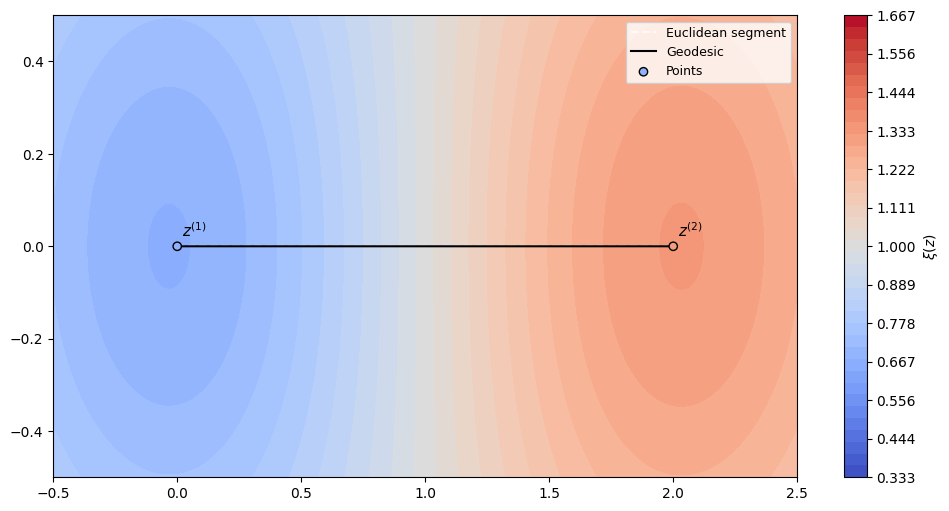

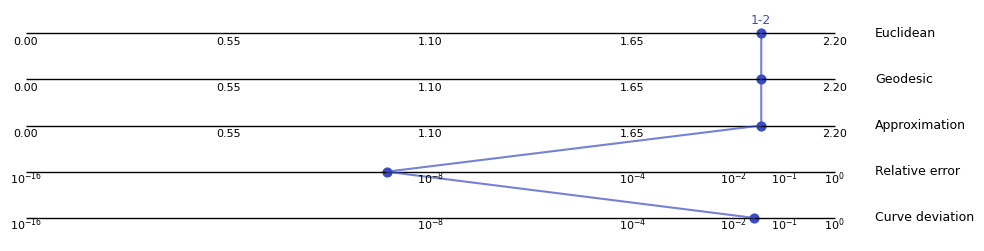

In [3]:
points = 2*np.array([[0,0], [1.0,0.0]])
weights = np.array([2/3, 4/3])
sigma = 2**(-1/2)
df,paths = run_experiment(points,weights,sigma)
print(df)
plot_geometry(points,weights,sigma,paths, fsize=(12,6))
plot_numeric_scales_normalized(df, fsize=(12,3))

  pair  euclidean  geodesic  approximation  relative_error  curve_deviation
0  1-2        1.5  1.219792       1.228712    7.312609e-03         0.019554
1  1-3        2.0  2.000000       2.000000    1.355671e-09         0.025349
2  2-3        2.5  2.656236       2.865923    7.894148e-02         0.138884


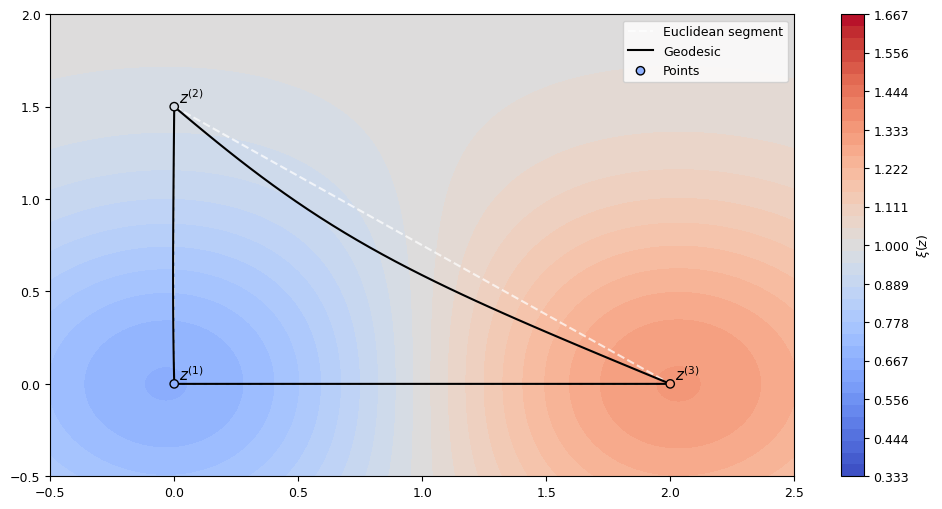

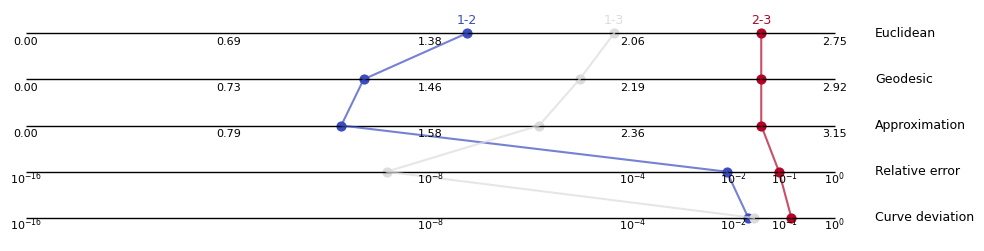

In [12]:
points = 2.5*np.array([[0,0], [0.0,0.6], [0.8,0.0]])
weights = np.array([2/3, 3/3, 4/3])
sigma = 2**(-1/2)
df,paths = run_experiment(points,weights,sigma)
print(df)
plot_geometry(points,weights,sigma,paths, fsize=(12,6))
plot_numeric_scales_normalized(df, fsize=(12,3))

  pair  euclidean  geodesic  approximation  relative_error  curve_deviation
0  1-2   1.414214  1.416308       1.415569        0.000522         0.018026
1  1-3   2.549510  2.548806       2.353958        0.076447         0.082004
2  1-4   3.000000  2.949457       2.374930        0.194791         0.079673
3  2-3   2.121320  2.488747       2.571079        0.033082         0.053801
4  2-4   2.236068  2.437084       2.415766        0.008747         0.080423
5  3-4   0.707107  0.709204       0.709018        0.000262         0.008997


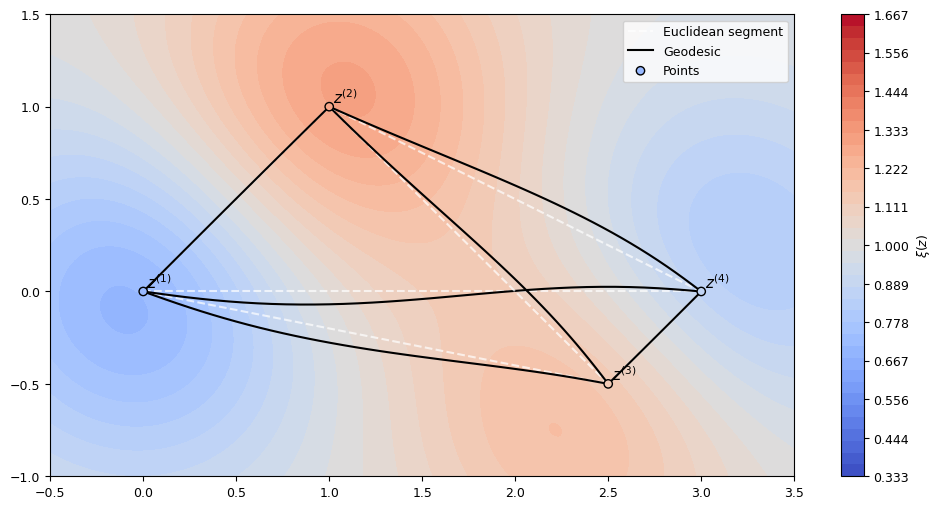

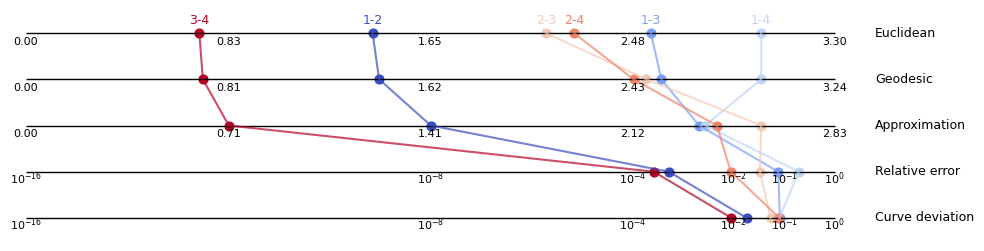

In [5]:
points = np.array([[0,0], [1.0,1.0], [2.5,-0.5], [3.0,0.0]])
weights = np.array([2/3, 4/3, 4/3, 2/3])
sigma = 2**(-1/2)
df,paths = run_experiment(points,weights,sigma)
print(df)
plot_geometry(points,weights,sigma,paths, fsize=(12,6))
plot_numeric_scales_normalized(df, fsize=(12,3))

  pair  euclidean  geodesic  approximation  relative_error  curve_deviation
0  1-2   1.414214  1.412108       1.412858        0.000531         0.018073
1  1-3   2.549510  2.534465       2.745061        0.083093         0.103321
2  1-4   3.000000  3.029785       3.625070        0.196478         0.104918
3  2-3   2.121320  1.747463       1.671561        0.043435         0.050670
4  2-4   2.236068  2.019267       2.056370        0.018374         0.088233
5  3-4   0.707107  0.705004       0.705195        0.000271         0.008990


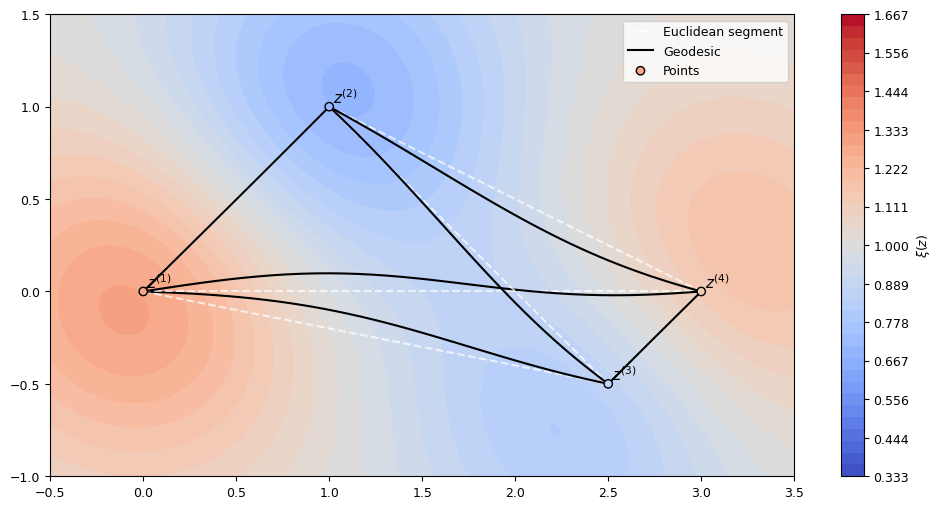

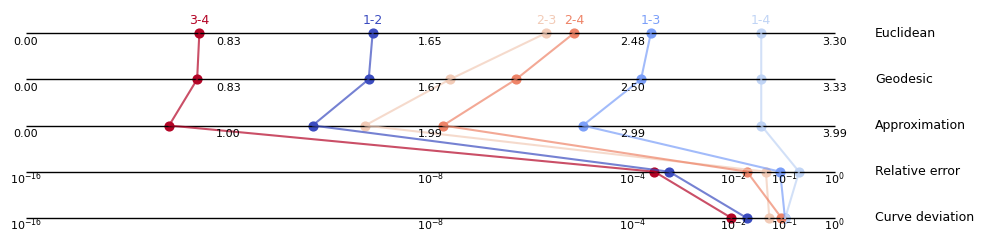

In [13]:
points = np.array([[0,0], [1.0,1.0], [2.5,-0.5], [3.0,0.0]])
weights = np.array([4/3, 2/3, 2/3, 4/3])
sigma = 2**(-1/2)
df,paths = run_experiment(points,weights,sigma)
print(df)
plot_geometry(points,weights,sigma,paths, fsize=(12,6))
plot_numeric_scales_normalized(df, fsize=(12,3))

## Experiment 2

,xi1,xi2,xi3,p12,p13,p23
0,0.5,0.5,0.5,0.6225,0.6225,0.6225
1,0.5,0.5,1.0,0.6225,0.5622,0.5622
2,0.5,0.5,5.0,0.6225,0.1480,0.1480
3,0.5,1.0,1.0,0.5622,0.5622,0.5000
4,0.5,1.0,5.0,0.5622,0.1480,0.1192
5,0.5,5.0,5.0,0.1480,0.1480,0.0180
6,1.0,1.0,1.0,0.5000,0.5000,0.5000
7,1.0,1.0,5.0,0.5000,0.1192,0.1192
8,1.0,5.0,5.0,0.1192,0.1192,0.0180
9,5.0,5.0,5.0,0.0180,0.0180,0.0180


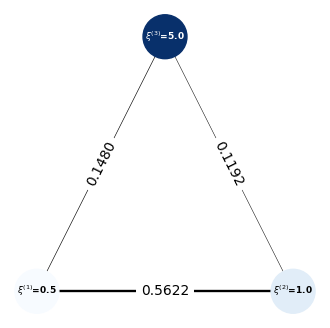

In [4]:
import itertools
import numpy as np
import pandas as pd
def expit(x):
    return 1 / (1 + np.exp(-x))
def toy_lsm_xi(xi_values,d12=1.0,d13=1.0,d23=1.0,alpha=1.0):
    rows = []
    for xi1, xi2, xi3 in itertools.product(xi_values, repeat=3):
        w12 = (xi1 + xi2) / 2
        w13 = (xi1 + xi3) / 2
        w23 = (xi2 + xi3) / 2
        s12 = alpha - w12 * d12
        s13 = alpha - w13 * d13
        s23 = alpha - w23 * d23
        p12 = expit(s12)
        p13 = expit(s13)
        p23 = expit(s23)
        p = [p12, p13, p23]
        #rows.append({"xi1": xi1,"xi2": xi2,"xi3": xi3,"d12": d12,"d13": d13,"d23": d23,"p12": p12,"p13": p13,"p23": p23,"canon": tuple(sorted(p))})
        rows.append({"xi1": xi1,"xi2": xi2,"xi3": xi3,"p12": p12,"p13": p13,"p23": p23,"canon": tuple(sorted(p))})
    df = pd.DataFrame(rows)
    df = df.drop_duplicates(subset="canon")
    df = df.drop(columns="canon")
    df = df.reset_index(drop=True)
    return df


import networkx as nx
import matplotlib.pyplot as plt
def plot_toy_network(row):
    xi = [row["xi1"], row["xi2"], row["xi3"]]
    p = [row["p12"], row["p13"], row["p23"]]
    G = nx.Graph()
    G.add_nodes_from([1,2,3])
    G.add_edge(1,2,weight=p[0])
    G.add_edge(1,3,weight=p[1])
    G.add_edge(2,3,weight=p[2])
    pos = { 1:(0,0), 2:(1,0), 3:(0.5,0.9)}
    xi_array = np.array(xi)
    norm = plt.Normalize(vmin=xi_array.min(), vmax=xi_array.max())
    cmap = plt.cm.Blues
    node_colors = cmap(norm(xi_array))
    edge_widths = [3*(w) for w in p]
    plt.figure(figsize=(4,4))
    nx.draw_networkx_nodes(G,pos,node_color=node_colors,node_size=1000)
    nx.draw_networkx_edges(G, pos, width=edge_widths )
    for i, (x, y) in pos.items():
        xi_val = xi[i-1]
        color = node_colors[i-1]
        luminance = 0.299*color[0] + 0.587*color[1] + 0.114*color[2]
        text_color = "white" if luminance < 0.5 else "black"
        plt.text(x, y,  fr"$\xi^{{({i})}}$={xi_val}", ha="center", va="center", fontsize=6.5, color=text_color, fontweight="bold")
    edge_labels = { (1,2): f"{p[0]:.4f}", (1,3): f"{p[1]:.4f}", (2,3): f"{p[2]:.4f}"   }
    nx.draw_networkx_edge_labels(G,  pos, edge_labels=edge_labels,font_size=10)
    plt.axis("off")
    plt.show()

tabla_lsm_xi = toy_lsm_xi(xi_values=[0.5,1.0,5.0], d12=1.0,d13=1.0,  d23=1.0,alpha=1.0)
display(tabla_lsm_xi.round(4))
#tabla_lsm_xi.to_latex(index=False)
plot_toy_network(tabla_lsm_xi.iloc[4])

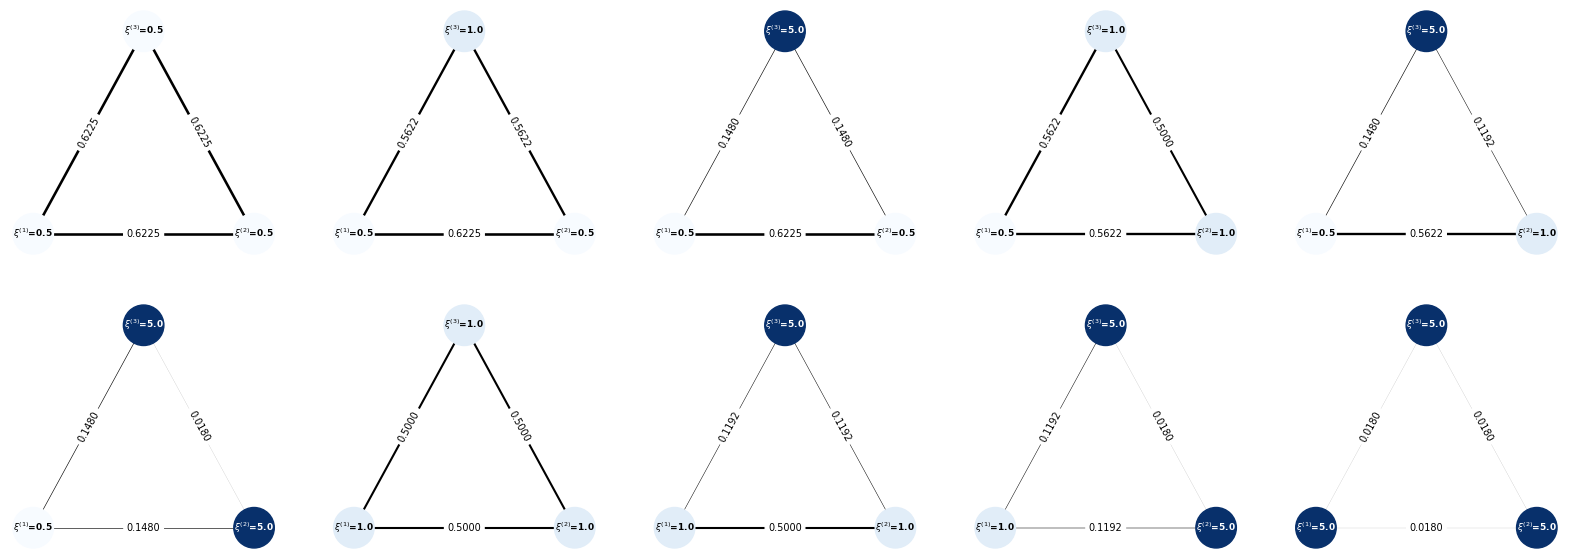

In [5]:

GLOBAL_VMIN = tabla_lsm_xi[["xi1","xi2","xi3"]].values.min()
GLOBAL_VMAX = tabla_lsm_xi[["xi1","xi2","xi3"]].values.max()
def plot_toy_network_ax(row, ax):
    xi = [row["xi1"], row["xi2"], row["xi3"]]
    p = [row["p12"], row["p13"], row["p23"]]

    

    G = nx.Graph()
    G.add_nodes_from([1,2,3])
    G.add_edge(1,2,weight=p[0])
    G.add_edge(1,3,weight=p[1])
    G.add_edge(2,3,weight=p[2])

    pos = {1:(0,0), 2:(1,0), 3:(0.5,0.9)}

    xi_array = np.array(xi)
    norm = plt.Normalize(vmin=GLOBAL_VMIN, vmax=GLOBAL_VMAX)
    cmap = plt.cm.Blues
    node_colors = cmap(norm(xi_array))

    edge_widths = [3*(w) for w in p]

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=850, ax=ax)
    nx.draw_networkx_edges(G, pos, width=edge_widths, ax=ax)

    for i, (x, y) in pos.items():
        xi_val = xi[i-1]
        color = node_colors[i-1]
        luminance = 0.299*color[0] + 0.587*color[1] + 0.114*color[2]
        text_color = "white" if luminance < 0.5 else "black"

        ax.text(x, y,
                fr"$\xi^{{({i})}}$={xi_val}",
                ha="center", va="center",
                fontsize=6.5,
                color=text_color,
                fontweight="bold")

    edge_labels = {
        (1,2): f"{p[0]:.4f}",
        (1,3): f"{p[1]:.4f}",
        (2,3): f"{p[2]:.4f}"
    }

    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, ax=ax)

    ax.set_axis_off()


fig, axes = plt.subplots(2, 5, figsize=(20,7))

for i, ax in enumerate(axes.flatten()):
    if i < len(tabla_lsm_xi):
        plot_toy_network_ax(tabla_lsm_xi.iloc[i], ax)
    else:
        ax.axis("off")
plt.show()

## Experiment 3

Row 0: xi1=0.5, xi2=0.5, xi3=0.5


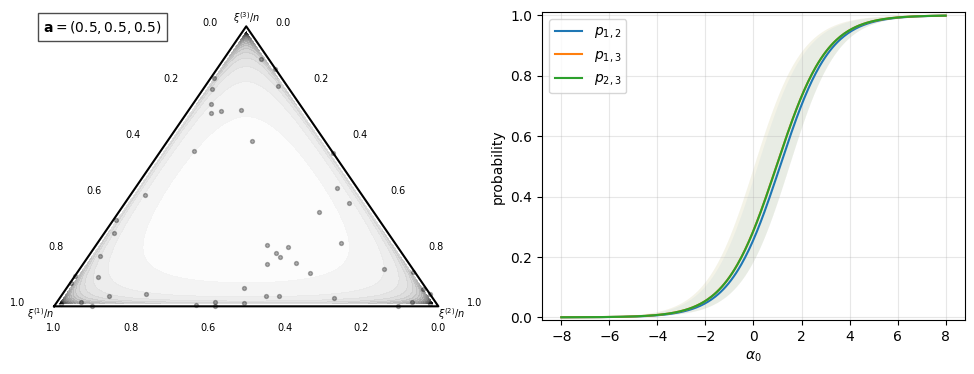

Row 1: xi1=0.5, xi2=0.5, xi3=1.0


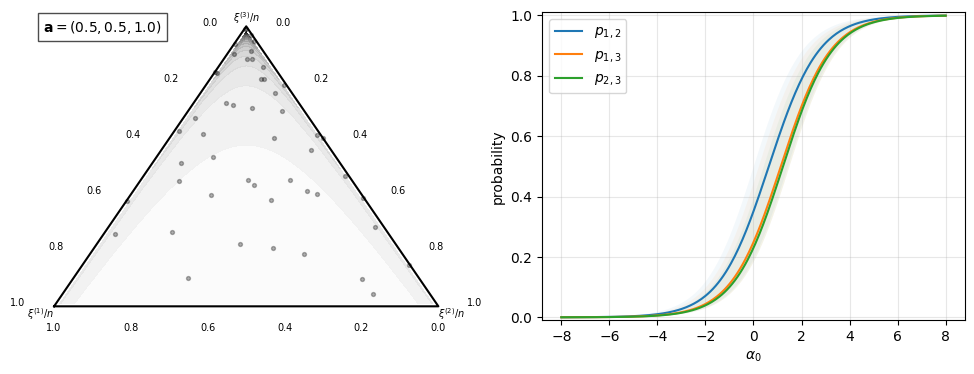

Row 2: xi1=0.5, xi2=0.5, xi3=5.0


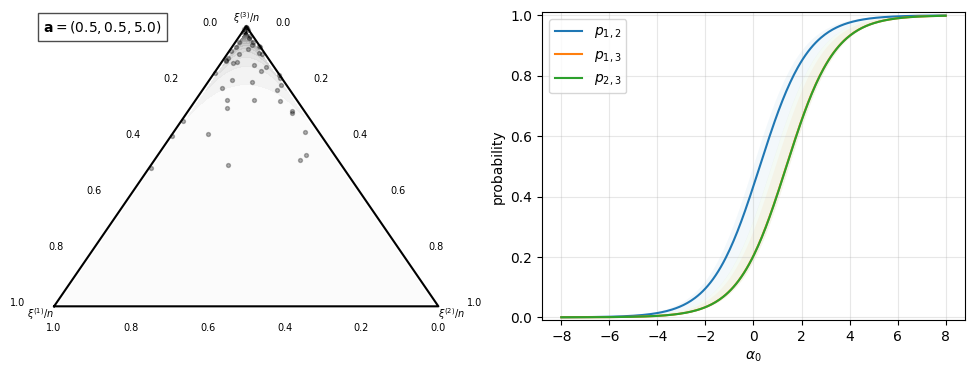

Row 3: xi1=0.5, xi2=1.0, xi3=1.0


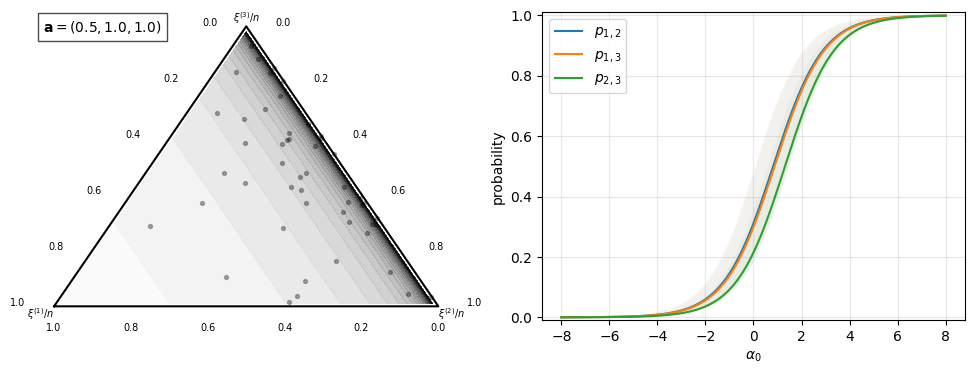

Row 4: xi1=0.5, xi2=1.0, xi3=5.0


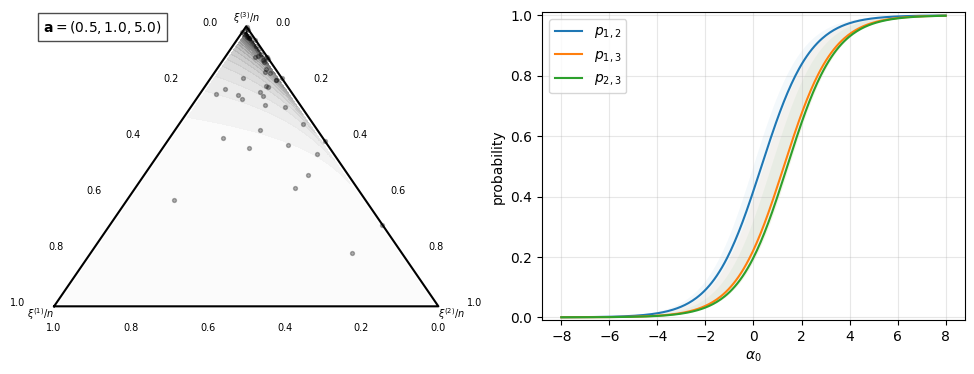

Row 5: xi1=0.5, xi2=5.0, xi3=5.0


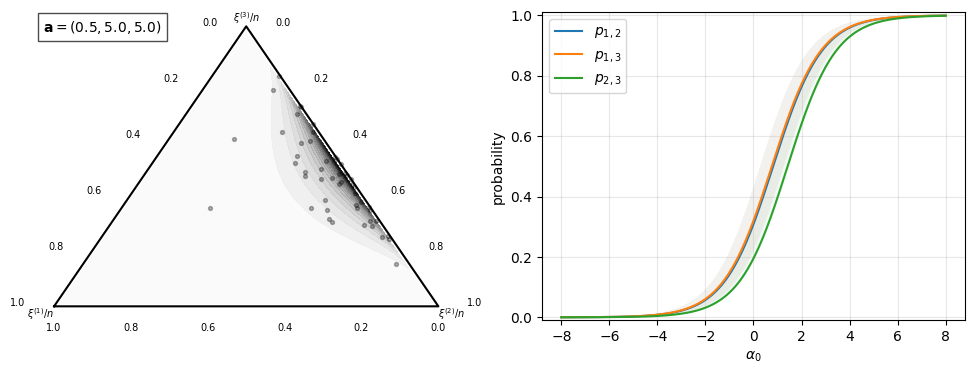

Row 6: xi1=1.0, xi2=1.0, xi3=1.0


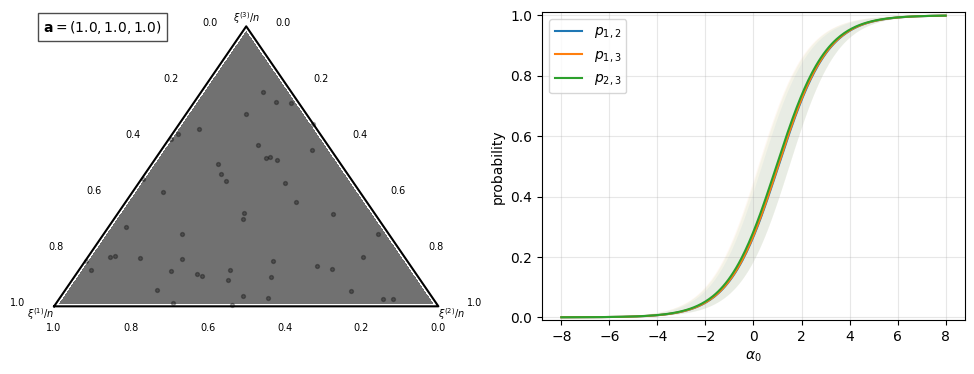

Row 7: xi1=1.0, xi2=1.0, xi3=5.0


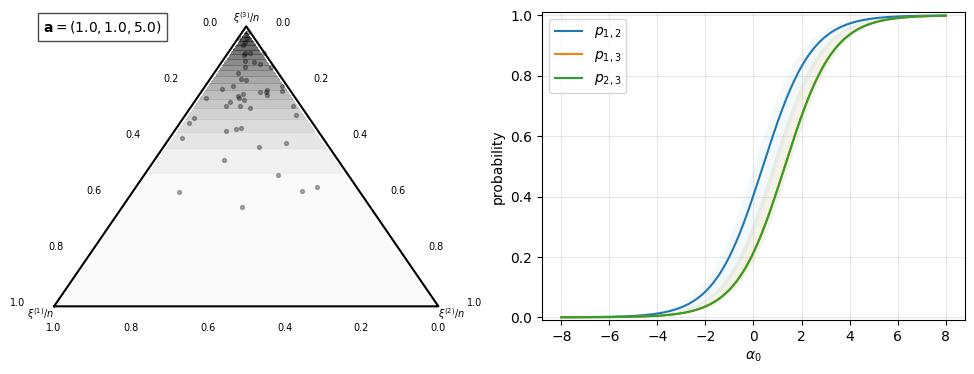

Row 8: xi1=1.0, xi2=5.0, xi3=5.0


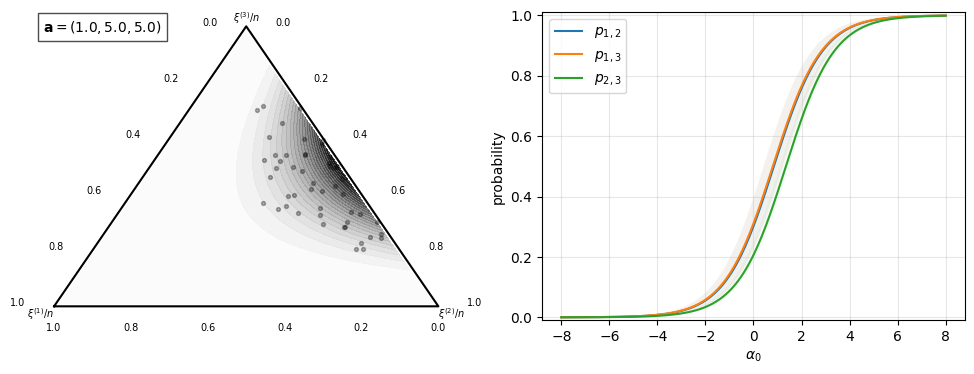

Row 9: xi1=5.0, xi2=5.0, xi3=5.0


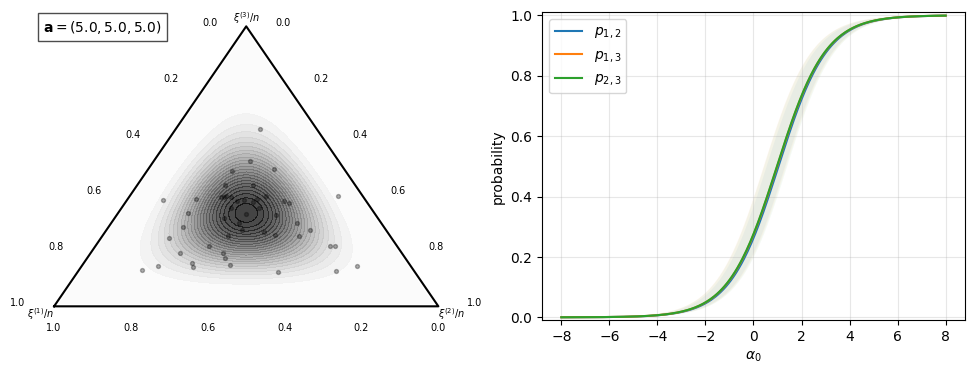

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from scipy.stats import dirichlet

def simplex_to_2d(x):
    x1, x2, x3 = x
    return np.array([x2 + 0.5 * x3,(np.sqrt(3)/2) * x3])

def params_to_probabilities(xi1,xi2,xi3,d12=1.0,d13=1.0,d23=1.0,alpha0=1.0):
    w12 = (xi1 + xi2) / 2
    w13 = (xi1 + xi3) / 2
    w23 = (xi2 + xi3) / 2
    s12 = alpha0 - w12 * d12
    s13 = alpha0 - w13 * d13
    s23 = alpha0 - w23 * d23
    p12 = 1 / (1 + np.exp(-s12))
    p13 = 1 / (1 + np.exp(-s13))
    p23 = 1 / (1 + np.exp(-s23))
    return np.array([p12, p13, p23])


def dirichlet_lsm_visualization(alpha_dirichlet,t=500,d12=1.0, d13=1.0, d23=1.0,alpha_range=(-3,3), n_alpha=100):
    n = 3
    x_samples = np.random.dirichlet(alpha_dirichlet, size=t)
    xi_samples = n * x_samples  
    pts2d = np.array([simplex_to_2d(x) for x in x_samples])
    grid = []
    res = 100
    eps = 1e-8

    for i in range(res):
        for j in range(res):
            x1 = i / res
            x2 = j / res
            x3 = 1 - x1 - x2
            if x1 > eps and x2 > eps and x3 > eps:
                grid.append([x1,x2,x3])

    grid = np.array(grid)
    grid2d = np.array([simplex_to_2d(x) for x in grid])
    density = dirichlet.pdf(grid.T, alpha_dirichlet)
    
    triang = tri.Triangulation(grid2d[:,0], grid2d[:,1])
    alpha_vals = np.linspace(alpha_range[0], alpha_range[1], n_alpha)
    probs_all = []
    for a0 in alpha_vals:
        probs = np.array([params_to_probabilities(*xi, d12, d13,d23,alpha0=a0)  for xi in xi_samples])
        probs_all.append(probs)
    probs_all = np.array(probs_all)
    mean = probs_all.mean(axis=1)
    min_ = probs_all.min(axis=1)
    max_ = probs_all.max(axis=1)
    fig, axes = plt.subplots(1,2, figsize=(12,4))
    ax = axes[0]
    ax.tricontourf(triang, density, levels=25, cmap="gray_r", alpha=0.75)
    ax.scatter(pts2d[:,0], pts2d[:,1], color="black", s=8, alpha=0.3)
    v1 = simplex_to_2d([1,0,0])
    v2 = simplex_to_2d([0,1,0])
    v3 = simplex_to_2d([0,0,1])
    triangle = np.array([v1,v2,v3,v1])
    ax.plot(triangle[:,0], triangle[:,1], color="black")
    ax.text(*v1, r"$\xi^{(1)}/n$", ha="right", va="top", fontsize=7)
    ax.text(*v2, r"$\xi^{(2)}/n$", ha="left", va="top", fontsize=7)
    ax.text(*v3, r"$\xi^{(3)}/n$", ha="center", va="bottom", fontsize=7)
    ticks = np.linspace(0,1,6)
    
    for t in ticks:
        p = simplex_to_2d([t,1-t,0])
        ax.text(p[0], p[1]-0.075, f"{t:.1f}", ha="center", fontsize=7)
        p = simplex_to_2d([t,0,1-t])
        ax.text(p[0]-0.075, p[1], f"{t:.1f}", ha="right", fontsize=7)
        p = simplex_to_2d([0,t,1-t])
        ax.text(p[0]+0.075, p[1], f"{t:.1f}", ha="left", fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("off")
    ax.annotate(
        rf"$\mathbf{{a}} = {tuple(alpha_dirichlet)}$",
        xy=(0.02, 0.98),
        xycoords="axes fraction",
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.7)
    )
    ax = axes[1]
    labels = [r"$p_{1,2}$",r"$p_{1,3}$",r"$p_{2,3}$"]
    for i in range(3):
        ax.plot(alpha_vals, mean[:,i], label=labels[i])
        ax.fill_between(alpha_vals, min_[:,i], max_[:,i], alpha=0.05)
    ax.set_ylim(-0.1,1.1)
    ax.set_xlabel(r"$\alpha_0$")
    ax.set_ylabel("probability")
    ax.set_ylim(-0.01,1.01)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()
    
for i in range(len(tabla_lsm_xi)):
    xi1 = float(tabla_lsm_xi.iloc[i]['xi1'])
    xi2 = float(tabla_lsm_xi.iloc[i]['xi2'])
    xi3 = float(tabla_lsm_xi.iloc[i]['xi3'])
    print(f"Row {i}: xi1={xi1}, xi2={xi2}, xi3={xi3}")
    dirichlet_lsm_visualization(alpha_dirichlet=[xi1, xi2, xi3], t=50, d12=1.0, d13=1.0, d23=1.0,alpha_range=(-8,8),n_alpha=300)

## Experiment 4

In [7]:

import numpy as np
import matplotlib.pyplot as plt

def sample_latent_positions(n, d, D, geometry="euclidean", seed=None):
    """
    Sample n points in dimension d under a geometry with diameter constraint D.

    Parameters
    ----------
    n : int
    d : int (1 or 2)
    D : float (max diameter)
    geometry : str ("euclidean", "spherical", "hyperbolic")
    seed : int or None

    Returns
    -------
    z : array of shape (n, dim_embedding)
    """
    rng = np.random.default_rng(seed)
    if geometry == "euclidean":
        direction = rng.normal(size=(n, d))
        direction = direction / np.linalg.norm(direction, axis=1, keepdims=True)
        u = rng.uniform(size=(n, 1))
        radius = (D / 2) * u ** (1.0 / d)
        z = radius * direction
        return z
    elif geometry == "spherical":
        R = D / np.pi
        x = rng.normal(size=(n, d + 1))
        x = x / np.linalg.norm(x, axis=1, keepdims=True)
        z = R * x
        return z

    elif geometry == "hyperbolic":
        assert d in [1, 2], "Exact sampler implemented for d=1 or d=2"
        R = D / np.pi
        if d == 1:
            direction = rng.choice([-1.0, 1.0], size=(n, 1))
        elif d == 2:
            theta = rng.uniform(0.0, 2 * np.pi, size=(n, 1))
            direction = np.concatenate([np.cos(theta), np.sin(theta)], axis=1)
        if d == 1:
            r = (D / 2) * u
        elif d == 2:
            alpha = 1.0
            u = rng.uniform(size=(n, 1))
            r = (1/alpha) * np.arccosh(1 + u * (np.cosh(alpha * (D/2)) - 1))
        norm = r / R
        cosh_term = np.cosh(norm)
        sinh_term = np.sinh(norm)

        spatial = R * sinh_term * direction
        time = R * cosh_term

        z = np.concatenate([spatial, time], axis=1)

        return z

    else:
        raise ValueError("geometry must be 'euclidean', 'spherical' or 'hyperbolic'")

def pairwise_distances_euclidean(Z):
    n = Z.shape[0]
    D = []
    for i in range(n):
        for j in range(i+1, n):
            D.append(np.linalg.norm(Z[i] - Z[j]))
    return np.array(D)

def pairwise_distances_spherical(Z, R):
    n = Z.shape[0]
    D = []
    for i in range(n):
        for j in range(i+1, n):
            cos_angle = np.dot(Z[i], Z[j]) / R**2
            cos_angle = np.clip(cos_angle, -1, 1)
            D.append(R * np.arccos(cos_angle))
    return np.array(D)

def pairwise_distances_hyperbolic(Z, R):
    def lorentz_dot(x, y):
        return np.dot(x[:-1], y[:-1]) - x[-1]*y[-1]
    n = Z.shape[0]
    D = []
    for i in range(n):
        for j in range(i+1, n):
            val = -lorentz_dot(Z[i], Z[j]) / R**2 + 1e-6
            val = np.clip(val, 1, None)
            D.append(R * np.arccosh(val))
    return np.array(D)

def apply_xi(distances, Z, xi):
    n = Z.shape[0]
    D_mod = []
    k = 0
    for i in range(n):
        for j in range(i+1, n):
            factor = (xi[i] + xi[j]) / 2
            D_mod.append(factor * distances[k])
            k += 1
    return np.array(D_mod)


# Experiment
n = 200
d = 2
D = 10
R = D / np.pi
z_euc = sample_latent_positions(n, d, D, "euclidean", seed=0)
z_sph = sample_latent_positions(n, d, D, "spherical", seed=0)
z_hyp = sample_latent_positions(n, d, D, "hyperbolic", seed=0)
xi_sim = n*np.random.dirichlet(1e0*np.ones(n), size=1)
xi_sim = xi_sim.flatten()
d_euc = pairwise_distances_euclidean(z_euc)
d_sph = pairwise_distances_spherical(z_sph, D / np.pi)
d_hyp = pairwise_distances_hyperbolic(z_hyp, D / np.pi)
d_euc_xi = apply_xi(d_euc, z_euc, xi_sim)
d_sph_xi = apply_xi(d_sph, z_sph, xi_sim)
d_hyp_xi = apply_xi(d_hyp, z_hyp, xi_sim)

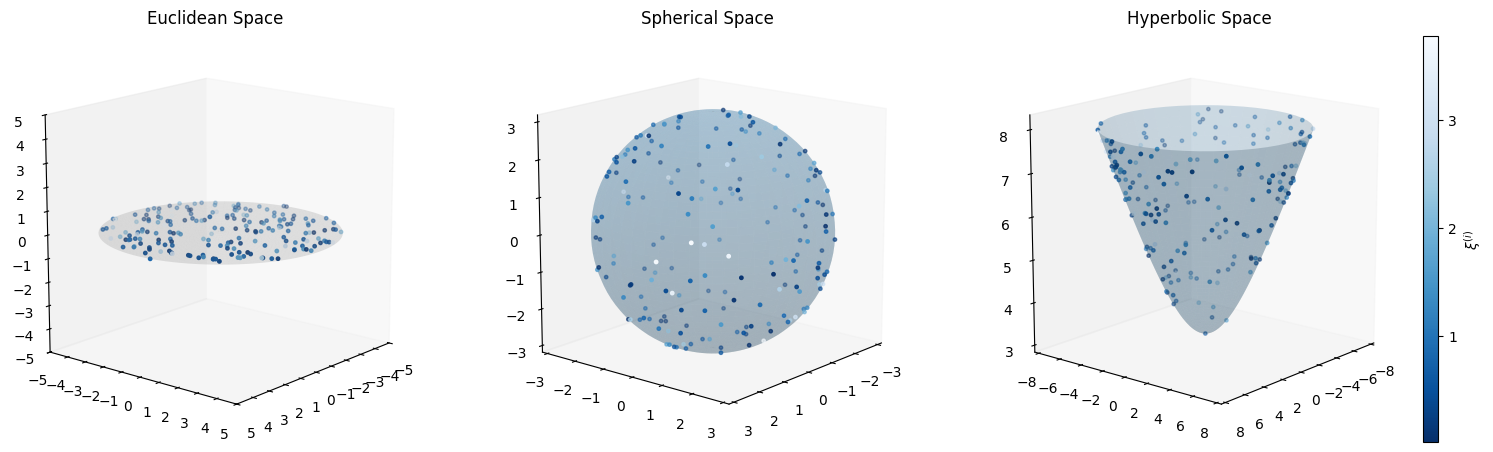

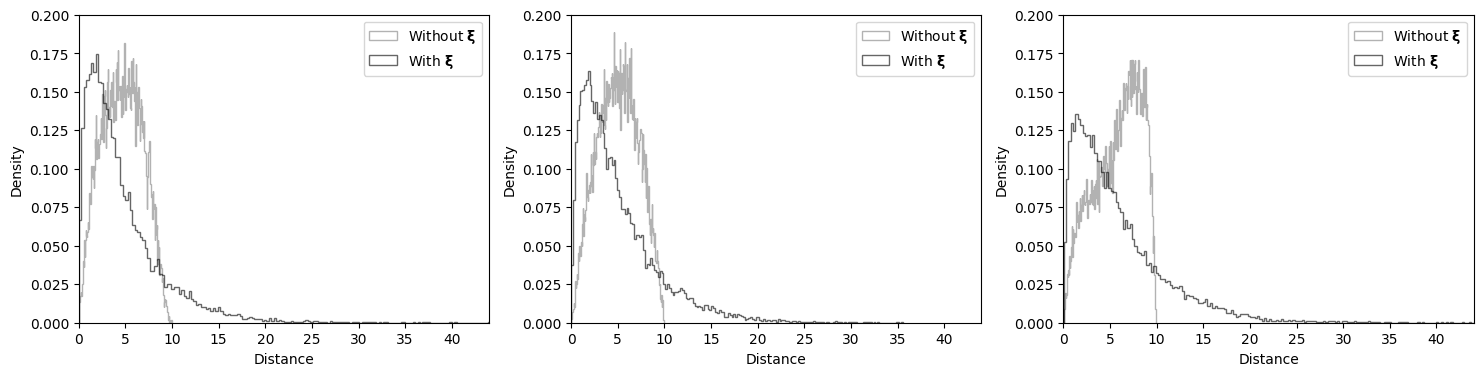

In [8]:

norm = plt.Normalize(vmin=np.percentile(xi_sim, 1), vmax=np.percentile(xi_sim, 99))
fig = plt.figure(figsize=(18, 6))
ax1 = fig.add_subplot(131, projection='3d')
z_euc_3d = np.concatenate([z_euc, np.zeros((z_euc.shape[0], 1))], axis=1)
ax1.scatter(z_euc_3d[:, 0], z_euc_3d[:, 1], z_euc_3d[:, 2], c=xi_sim, cmap="Blues_r", s=6, norm=norm)
theta = np.linspace(0, 2*np.pi, 100)
r = np.linspace(0, D/2, 50)
Theta, R_grid = np.meshgrid(theta, r)
X = R_grid * np.cos(Theta)
Y = R_grid * np.sin(Theta)
Z = np.zeros_like(X)
ax1.plot_surface(X, Y, Z, color="lightgray", alpha=0.2)
ax1.set_title("Euclidean Space")
ax1.set_xlim(-D/2, D/2)
ax1.set_ylim(-D/2, D/2)
ax1.set_zlim(-D/2, D/2)
ax1.view_init(elev=15, azim=40)
ax1.set_box_aspect([1,1,1])

ax2 = fig.add_subplot(132, projection='3d')
u = np.linspace(0, 2*np.pi, 50)
v = np.linspace(0, np.pi, 50)
x = R * np.outer(np.cos(u), np.sin(v))
y = R * np.outer(np.sin(u), np.sin(v))
z = R * np.outer(np.ones_like(u), np.cos(v))
ax2.plot_surface(x, y, z, alpha=0.2)
ax2.scatter(z_sph[:, 0], z_sph[:, 1], z_sph[:, 2], c=xi_sim, cmap="Blues_r", s=6, norm=norm)
ax2.set_title("Spherical Space")
ax2.set_xlim(-R, R)
ax2.set_ylim(-R, R)
ax2.set_zlim(-R, R)
ax2.view_init(elev=15, azim=40)
ax2.set_box_aspect([1,1,1])



ax3 = fig.add_subplot(133, projection='3d')
u = np.linspace(0, 2*np.pi, 50)
r_vals = np.linspace(0, D/2, 50)
U, R_grid = np.meshgrid(u, r_vals)
X = R * np.sinh(R_grid / R) * np.cos(U)
Y = R * np.sinh(R_grid / R) * np.sin(U)
Z = R * np.cosh(R_grid / R)
ax3.plot_surface(X, Y, Z, alpha=0.2)
ax3.scatter(z_hyp[:, 0], z_hyp[:, 1], z_hyp[:, 2], c=xi_sim, cmap="Blues_r", s=6, norm=norm)
ax3.set_title("Hyperbolic Space")
ax3.view_init(elev=15, azim=40)
ax3.set_box_aspect([1,1,1])

from matplotlib.ticker import MaxNLocator
for ax in [ax1, ax2, ax3]:
    ax.grid(False)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.zaxis.set_major_locator(MaxNLocator(integer=True))
pos = ax3.get_position()
cax = fig.add_axes([pos.x1 + 0.01, pos.y0,0.0085, 0.99*pos.height])
sc = ax3.collections[-1]
cbar = fig.colorbar(sc, cax=cax)
cbar.set_label(r'$\xi^{{(i)}}$')
cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(18, 4))

bins = 180

axes[0].hist(d_euc, bins=bins, alpha=0.6, label=r'Without $\mathbf{{\xi}}$', density=True, histtype='step', color="gray")
axes[0].hist(d_euc_xi, bins=bins, alpha=0.6, label=r'With $\mathbf{{\xi}}$', density=True, histtype='step', color="black")
#axes[0].set_title("Euclidean")
axes[0].legend()

axes[1].hist(d_sph, bins=bins, alpha=0.6, label=r'Without $\mathbf{{\xi}}$', density=True, histtype='step', color="gray")
axes[1].hist(d_sph_xi, bins=bins, alpha=0.6, label=r'With $\mathbf{{\xi}}$', density=True, histtype='step', color="black")
#axes[1].set_title("Spherical")
axes[1].legend()

axes[2].hist(d_hyp, bins=bins, alpha=0.6, label=r'Without $\mathbf{{\xi}}$', density=True, histtype='step', color="gray")
axes[2].hist(d_hyp_xi, bins=bins, alpha=0.6, label=r'With $\mathbf{{\xi}}$', density=True, histtype='step', color="black")
#axes[0,2].set_title("Hyperbolic")
axes[2].legend()

max = 40
axes[0].set_xlim(0, max*1.1)
axes[1].set_xlim(0, max*1.1)
axes[2].set_xlim(0, max*1.1)
axes[0].set_ylim(0,0.2)
axes[1].set_ylim(0,0.2)
axes[2].set_ylim(0,0.2)
for ax in axes:
    ax.set_xlabel("Distance")
    ax.set_ylabel("Density")
plt.show()

In [9]:
def distance_matrix_euclidean(Z):
    diff = Z[:, None, :] - Z[None, :, :]
    return np.linalg.norm(diff, axis=-1)

def distance_matrix_spherical(Z, R):
    dot = Z @ Z.T / R**2
    dot = np.clip(dot, -1, 1)
    return R * np.arccos(dot)

def distance_matrix_hyperbolic(Z, R):
    def lorentz_dot_matrix(X, Y):
        return X[:, :-1] @ Y[:, :-1].T - np.outer(X[:, -1], Y[:, -1])
    
    L = lorentz_dot_matrix(Z, Z)
    val = -L / R**2
    val = np.clip(val, 1, None)
    return R * np.arccosh(val)


def apply_xi_matrix(D, xi):
    Xi = (xi[:, None] + xi[None, :]) / 2
    return Xi * D


def expit(x):
    return 1 / (1 + np.exp(-x))

alpha0 = 5.0  

D_euc = distance_matrix_euclidean(z_euc)
D_sph = distance_matrix_spherical(z_sph, R)
D_hyp = distance_matrix_hyperbolic(z_hyp, R)
D_euc_xi = apply_xi_matrix(D_euc, xi_sim)
D_sph_xi = apply_xi_matrix(D_sph, xi_sim)
D_hyp_xi = apply_xi_matrix(D_hyp, xi_sim)


P_euc = expit(alpha0 - D_euc)
P_sph = expit(alpha0 - D_sph)
P_hyp = expit(alpha0 - D_hyp)

P_euc_xi = expit(alpha0 - D_euc_xi)
P_sph_xi = expit(alpha0 - D_sph_xi)
P_hyp_xi = expit(alpha0 - D_hyp_xi)




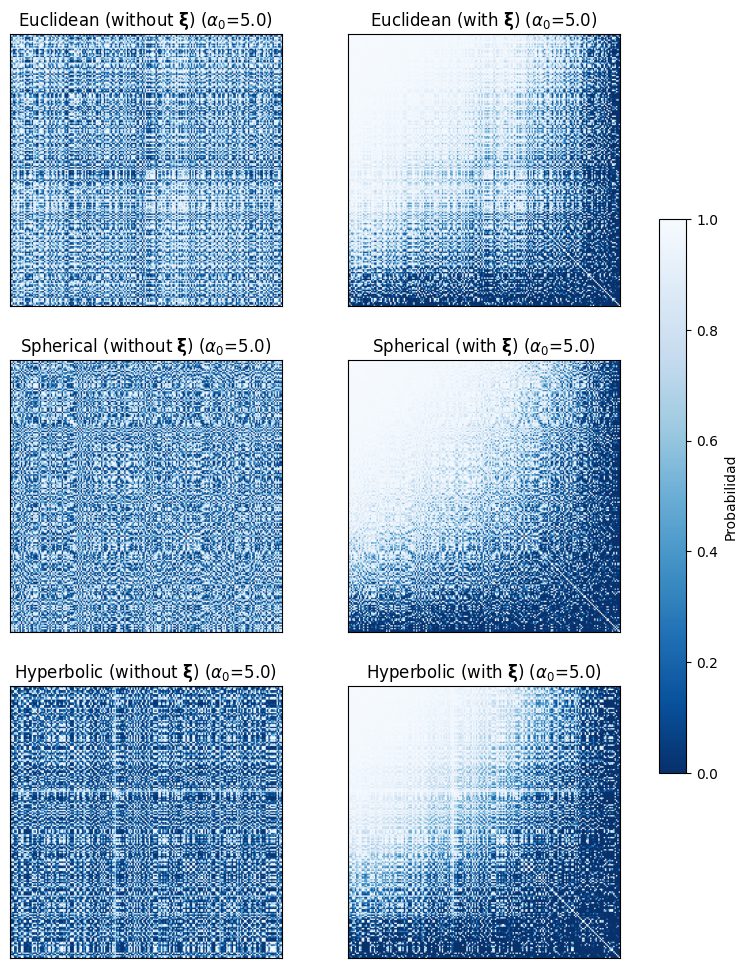

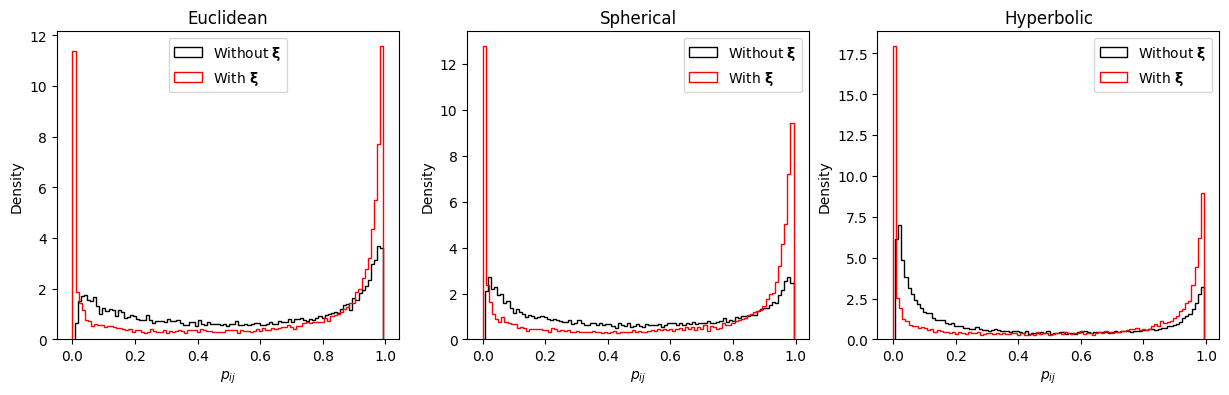

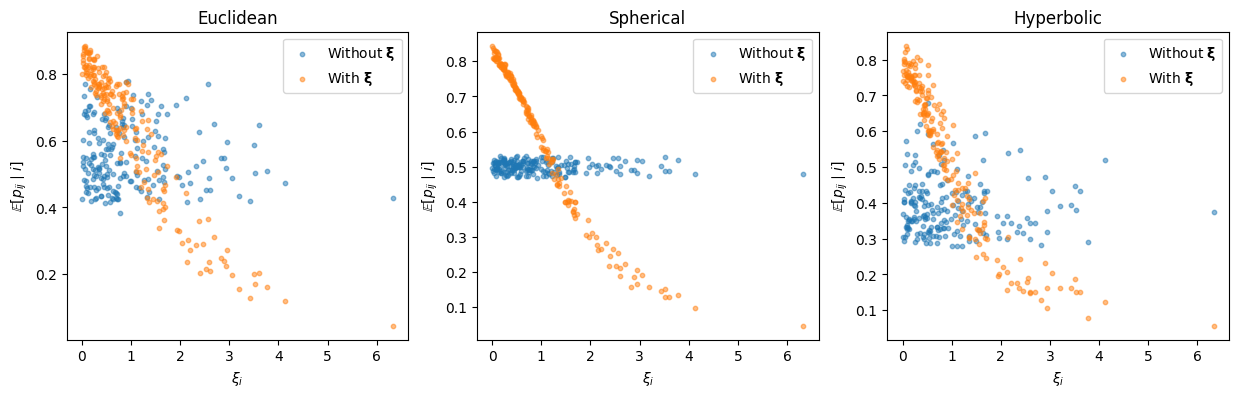

In [10]:

order = np.argsort(xi_sim)

def reorder_matrix(P, order):
    return P[order][:, order]


P_euc_ord     = reorder_matrix(P_euc, order)
P_euc_xi_ord  = reorder_matrix(P_euc_xi, order)

P_sph_ord     = reorder_matrix(P_sph, order)
P_sph_xi_ord  = reorder_matrix(P_sph_xi, order)

P_hyp_ord     = reorder_matrix(P_hyp, order)
P_hyp_xi_ord  = reorder_matrix(P_hyp_xi, order)


fig, axes = plt.subplots(3, 2, figsize=(10, 12))

titles = ["Euclidean", "Spherical", "Hyperbolic"]
Ps_ord = [(P_euc_ord, P_euc_xi_ord),
          (P_sph_ord, P_sph_xi_ord),
          (P_hyp_ord, P_hyp_xi_ord)]

for i, (P0, P1) in enumerate(Ps_ord):
    im0 = axes[i,0].imshow(P0, vmin=0, vmax=1, cmap="Blues_r")
    axes[i,0].set_title(fr"{titles[i]} (without $\mathbf{{\xi}}$) ($\alpha_0$={alpha0})")
    
    im1 = axes[i,1].imshow(P1, vmin=0, vmax=1, cmap="Blues_r")
    axes[i,1].set_title(fr"{titles[i]} (with $\mathbf{{\xi}}$) ($\alpha_0$={alpha0})")
    
    for j in range(2):
        axes[i,j].set_xticks([])
        axes[i,j].set_yticks([])

cbar = fig.colorbar(im1, ax=axes, shrink=0.6)
cbar.set_label("Probabilidad")

plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

Ps = [(P_euc, P_euc_xi),
      (P_sph, P_sph_xi),
      (P_hyp, P_hyp_xi)]

for i, (P0, P1) in enumerate(Ps):
    axes[i].hist(P0.flatten(), bins=100, density=True,
                 histtype='step', color='black', label=r'Without $\mathbf{{\xi}}$')
    
    axes[i].hist(P1.flatten(), bins=100, density=True,
                 histtype='step', color='red', label=r'With $\mathbf{{\xi}}$')
    
    axes[i].set_title(titles[i])
    axes[i].set_xlabel(r'$p_{ij}$')
    axes[i].set_ylabel("Density")
    axes[i].legend()

plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (P0, P1) in enumerate(Ps):
    mean_conn_no_xi = P0.mean(axis=1)
    mean_conn_xi    = P1.mean(axis=1)
    
    axes[i].scatter(xi_sim, mean_conn_no_xi,
                    s=10, alpha=0.5, label=r'Without $\mathbf{{\xi}}$')
    
    axes[i].scatter(xi_sim, mean_conn_xi,
                    s=10, alpha=0.5, label=r'With $\mathbf{{\xi}}$')
    
    axes[i].set_title(titles[i])
    axes[i].set_xlabel(r'$\xi_i$')
    axes[i].set_ylabel(r'$\mathbb{E}[p_{ij} \mid i]$')
    axes[i].legend()

plt.show()

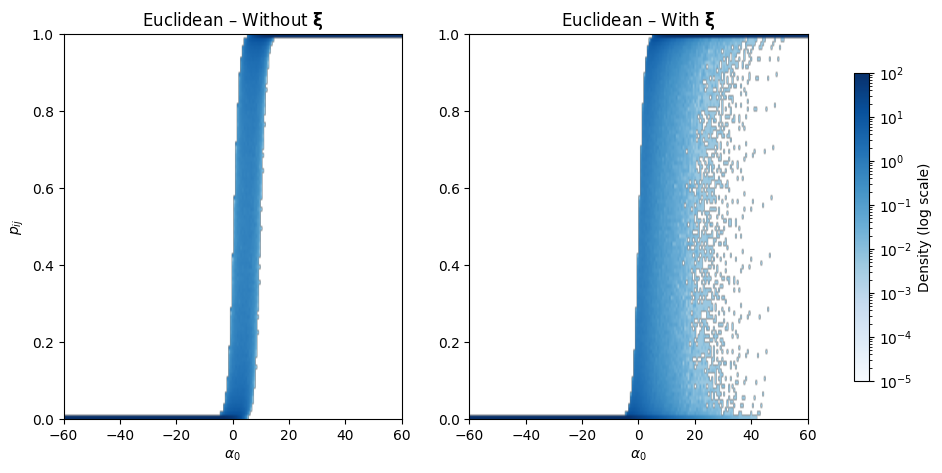

In [11]:

geometry = "euclidean"   # "euclidean", "spherical", "hyperbolic"
alpha_grid = np.linspace(-60, 60, 200)   # alpha0
bins = 100

if geometry == "euclidean":
    D_base = D_euc
    D_xi   = d_euc_xi
elif geometry == "spherical":
    D_base = d_sph
    D_xi   = d_sph_xi
elif geometry == "hyperbolic":
    D_base = d_hyp
    D_xi   = d_hyp_xi
else:
    raise ValueError("no geometry")

p_grid = np.linspace(0, 1, bins)
heat_no_xi = []
heat_with_xi = []
for alpha0 in alpha_grid:
    P0 = expit(alpha0 - D_base)
    hist0, _ = np.histogram(P0, bins=bins, range=(0,1), density=True)
    heat_no_xi.append(hist0)
    P1 = expit(alpha0 - D_xi)
    hist1, _ = np.histogram(P1, bins=bins, range=(0,1), density=True)
    heat_with_xi.append(hist1)
heat_no_xi = np.array(heat_no_xi)
heat_with_xi = np.array(heat_with_xi)

from matplotlib.colors import LogNorm
del max
vmax = max(heat_no_xi.max(), heat_with_xi.max())
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(
    heat_no_xi.T,
    aspect='auto',
    origin='lower',
    extent=[alpha_grid.min(), alpha_grid.max(), 0, 1],
    cmap='Blues',
    norm=LogNorm(vmin=1e-5, vmax=vmax)
)
axes[0].set_title(fr'{geometry.capitalize()} – Without $\mathbf{{\xi}}$')
axes[0].set_xlabel(r'$\alpha_0$')
axes[0].set_ylabel(r'$p_{ij}$')

im1 = axes[1].imshow(
    heat_with_xi.T,
    aspect='auto',
    origin='lower',
    extent=[alpha_grid.min(), alpha_grid.max(), 0, 1],
    cmap='Blues',
    norm=LogNorm(vmin=1e-5, vmax=vmax)
)
axes[1].set_title(fr'{geometry.capitalize()} – With $\mathbf{{\xi}}$')
axes[1].set_xlabel(r'$\alpha_0$')
cbar = fig.colorbar(im1, ax=axes, shrink=0.8)
cbar.set_label("Density (log scale)")
plt.show()

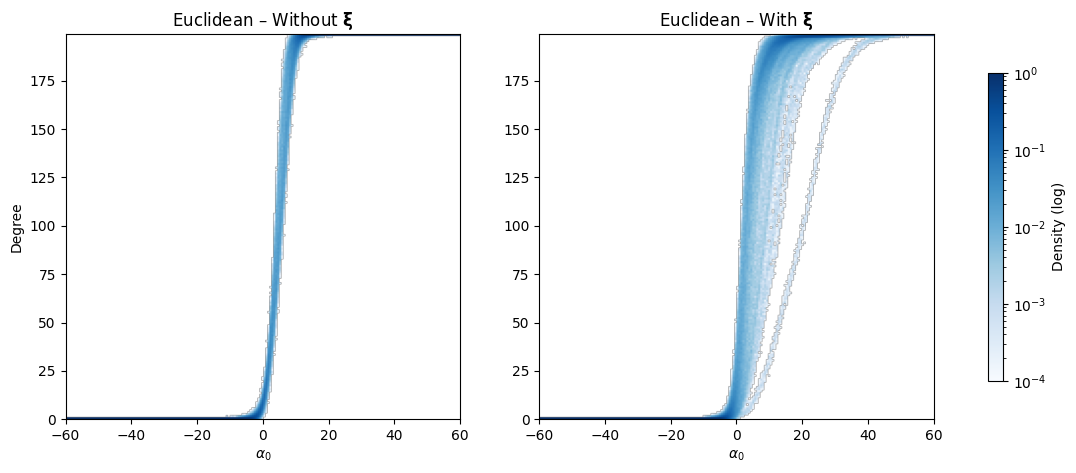

In [12]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit


def sample_network(P, rng):
    n = P.shape[0]
    A = rng.uniform(size=(n, n)) < P
    A = np.triu(A, 1)
    A = A + A.T
    return A.astype(int)

def degree_heatmap(D_base, D_xi, alpha_grid, n_sims=20, bins=50, seed=0):
    rng = np.random.default_rng(seed)
    n = D_base.shape[0]

    max_degree = n - 1
    degree_bins = np.arange(0, max_degree + 2)

    heat_no_xi = []
    heat_with_xi = []

    for alpha0 in alpha_grid:
        degs0_all = []
        degs1_all = []

        for _ in range(n_sims):
            P0 = expit(alpha0 - D_base)
            A0 = sample_network(P0, rng)
            degs0 = A0.sum(axis=1)
            degs0_all.extend(degs0)

            P1 = expit(alpha0 - D_xi)
            A1 = sample_network(P1, rng)
            degs1 = A1.sum(axis=1)
            degs1_all.extend(degs1)

        hist0, _ = np.histogram(degs0_all, bins=degree_bins, density=True)
        hist1, _ = np.histogram(degs1_all, bins=degree_bins, density=True)

        heat_no_xi.append(hist0)
        heat_with_xi.append(hist1)

    return np.array(heat_no_xi), np.array(heat_with_xi), degree_bins

geometry = "euclidean"  # "euclidean", "spherical", "hyperbolic"
if geometry == "euclidean":
    D_base = D_euc
    D_xi   = D_euc_xi
elif geometry == "spherical":
    D_base = D_sph
    D_xi   = D_sph_xi
elif geometry == "hyperbolic":
    D_base = D_hyp
    D_xi   = D_hyp_xi
else:
    raise ValueError("no geometry")
alpha_grid = np.linspace(-60, 60, 200)
bins = D_base.shape[0] - 1
heat_no_xi, heat_with_xi, degree_bins = degree_heatmap(
    D_base, D_xi, alpha_grid,
    n_sims=30,   
    bins=bins,
    seed=42
)
degree_vals = degree_bins[:-1]
from matplotlib.colors import LogNorm
vmax = max(heat_no_xi.max(), heat_with_xi.max())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im0 = axes[0].imshow(
    heat_no_xi.T,
    aspect='auto',
    origin='lower',
    extent=[alpha_grid.min(), alpha_grid.max(),
            degree_vals.min(), degree_vals.max()],
    cmap='Blues',
    norm=LogNorm(vmin=1e-4, vmax=vmax)
)
axes[0].set_title(fr"{geometry.capitalize()} – Without $\mathbf{{\xi}}$")
axes[0].set_xlabel(r'$\alpha_0$')
axes[0].set_ylabel("Degree")
im1 = axes[1].imshow(
    heat_with_xi.T,
    aspect='auto',
    origin='lower',
    extent=[alpha_grid.min(), alpha_grid.max(),
            degree_vals.min(), degree_vals.max()],
    cmap='Blues',
    norm=LogNorm(vmin=1e-4, vmax=vmax)
)
axes[1].set_title(fr"{geometry.capitalize()} – With $\mathbf{{\xi}}$")
axes[1].set_xlabel(r'$\alpha_0$')
cbar = fig.colorbar(im1, ax=axes, shrink=0.8)
cbar.set_label("Density (log)")
plt.show()

## Experiment 5

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.special import expit
from networkx.algorithms.community import greedy_modularity_communities

def sample_network(P, rng):
    n = P.shape[0]
    A = rng.uniform(size=(n, n)) < P
    A = np.triu(A, 1)
    A = A + A.T
    return A.astype(int)

def compute_stats(A):
    G = nx.from_numpy_array(A)
    m = G.number_of_edges()

    stats = {}
    degrees = np.array([deg for _, deg in G.degree()])
    stats["avg_degree"] = degrees.mean()
    stats["degree_sd"] = degrees.std()
    stats["density"] = nx.density(G)
    stats["transitivity"] = nx.transitivity(G)

    degrees = np.array([deg for _, deg in G.degree()])

    if len(degrees) == 0 or np.var(degrees) == 0:
        stats["assortativity"] = np.nan
    else:
        stats["assortativity"] = nx.degree_assortativity_coefficient(G)
    if m == 0:
        stats["avg_path_length"] = np.nan
        stats["diameter"] = np.nan
    else:
        if nx.is_connected(G):
            Gc = G
        else:
            Gc = G.subgraph(max(nx.connected_components(G), key=len)).copy()

        if Gc.number_of_nodes() > 1:
            stats["avg_path_length"] = nx.average_shortest_path_length(Gc)
            stats["diameter"] = nx.diameter(Gc)
        else:
            stats["avg_path_length"] = np.nan
            stats["diameter"] = np.nan
    try:
        comms = list(greedy_modularity_communities(G))
        stats["modularity"] = nx.community.modularity(G, comms)
    except:
        stats["modularity"] = 0
    stats["degree_centrality"] = np.mean(list(nx.degree_centrality(G).values()))
    stats["betweenness"] = np.mean(list(nx.betweenness_centrality(G).values()))
    stats["closeness"] = np.mean(list(nx.closeness_centrality(G).values()))

    return stats


def simulate_statistics(alpha_grid,n=50, d=2, D=10, t=5, c = 1, geometry="euclidean", seed=0):
    rng = np.random.default_rng(seed)

    results_no_xi = {k: [] for k in stat_names}
    results_xi    = {k: [] for k in stat_names}

    for alpha0 in alpha_grid:

        stats_no_xi = {k: [] for k in stat_names}
        stats_xi    = {k: [] for k in stat_names}

        for sim in range(t):

            # latent positions
            Z = sample_latent_positions(n, d, D, geometry, seed=rng.integers(1e9))
            # geometry-specific distance
            if geometry == "euclidean":
                Dmat = distance_matrix_euclidean(Z)
            elif geometry == "spherical":
                R = D / np.pi
                Dmat = distance_matrix_spherical(Z, R)
            elif geometry == "hyperbolic":
                R = D / np.pi
                Dmat = distance_matrix_hyperbolic(Z, R)
            # xi effects
            xi = n * rng.dirichlet(alpha=c*np.ones(n))
            Dmat_xi = apply_xi_matrix(Dmat, xi)
            # probabilities
            P0 = expit(alpha0 - Dmat)
            P1 = expit(alpha0 - Dmat_xi)
            # sample networks
            A0 = sample_network(P0, rng)
            A1 = sample_network(P1, rng)
            # compute stats
            s0 = compute_stats(A0)
            s1 = compute_stats(A1)
            for k in stat_names:
                stats_no_xi[k].append(s0[k])
                stats_xi[k].append(s1[k])
        # aggregate per alpha
        for k in stat_names:
            results_no_xi[k].append(stats_no_xi[k])
            results_xi[k].append(stats_xi[k])
    return results_no_xi, results_xi

# =========================
alpha_grid = np.linspace(-20, 20, 40)

stat_names = [
    "avg_degree",
    "degree_sd",
    "density",
    "transitivity",
    "assortativity",
    "avg_path_length",
    "diameter",
    "modularity",
    "degree_centrality",
    "betweenness",
    "closeness"
]
results_all = {}
for geom in ["euclidean", "spherical", "hyperbolic"]:
    res_no_xi, res_xi = simulate_statistics(alpha_grid, n=60, d=2,  D=10, t=50, c=1, geometry=geom, seed=42)
    results_all[geom] = (res_no_xi, res_xi)

C:\Users\carlo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\networkx\algorithms\assortativity\correlation.py:302: RuntimeWarning: invalid value encountered in scalar divide
  return float((xy * (M - ab)).sum() / np.sqrt(vara * varb))


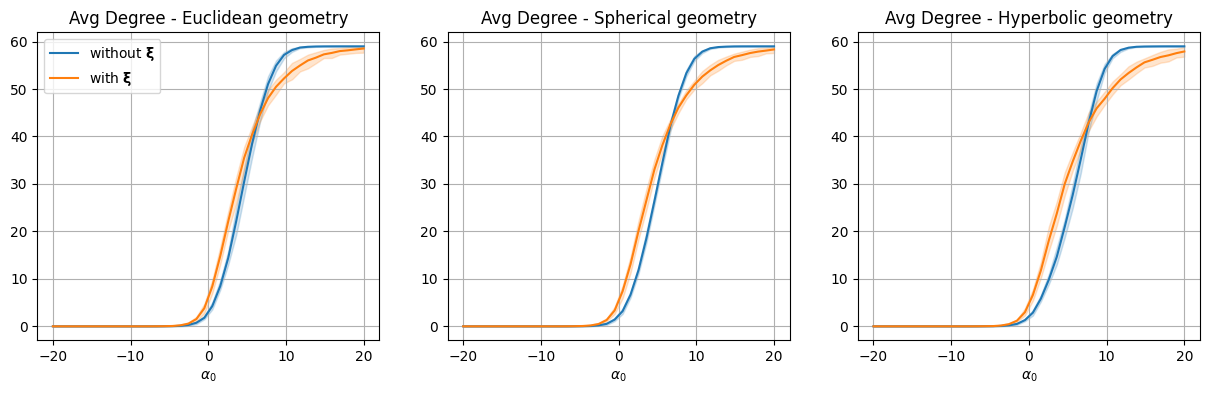

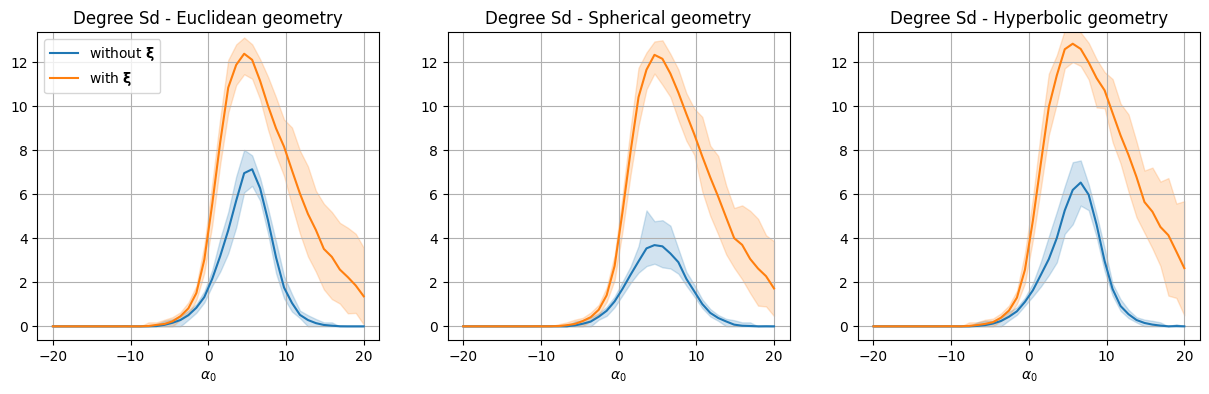

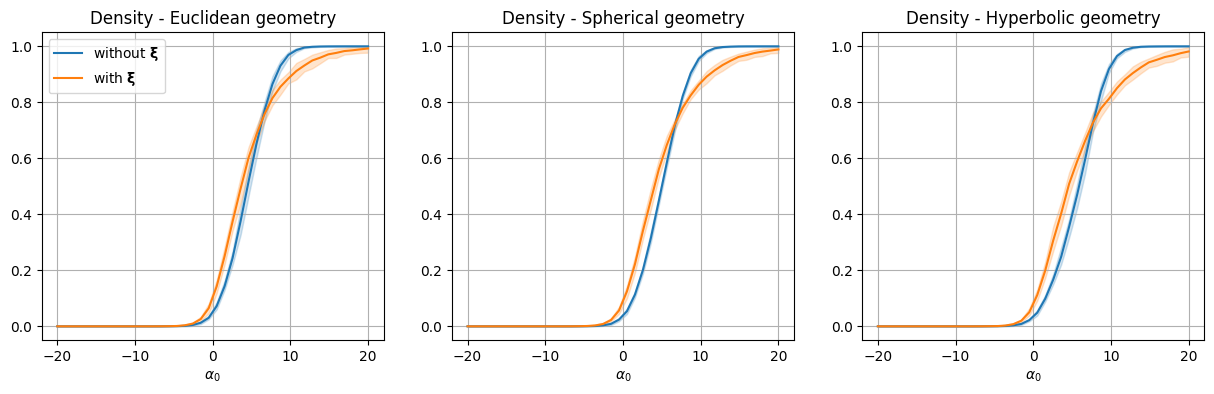

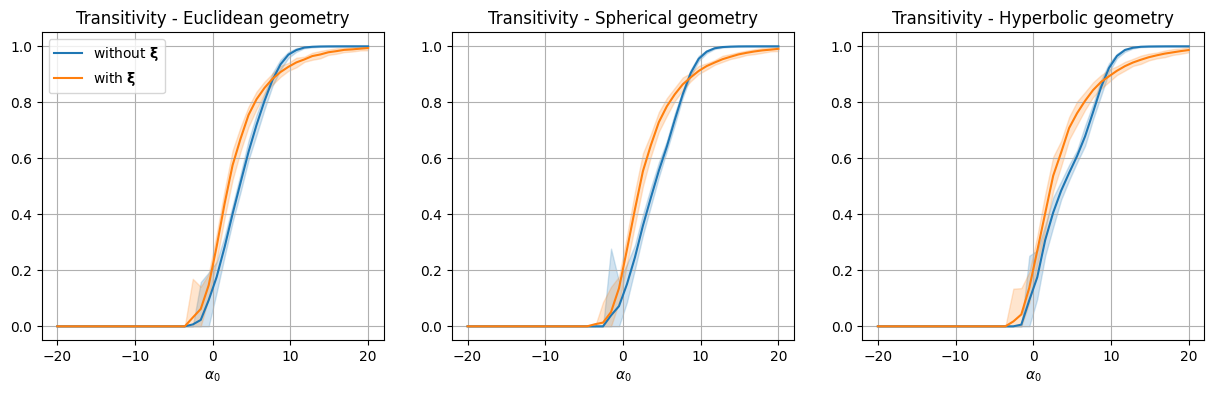

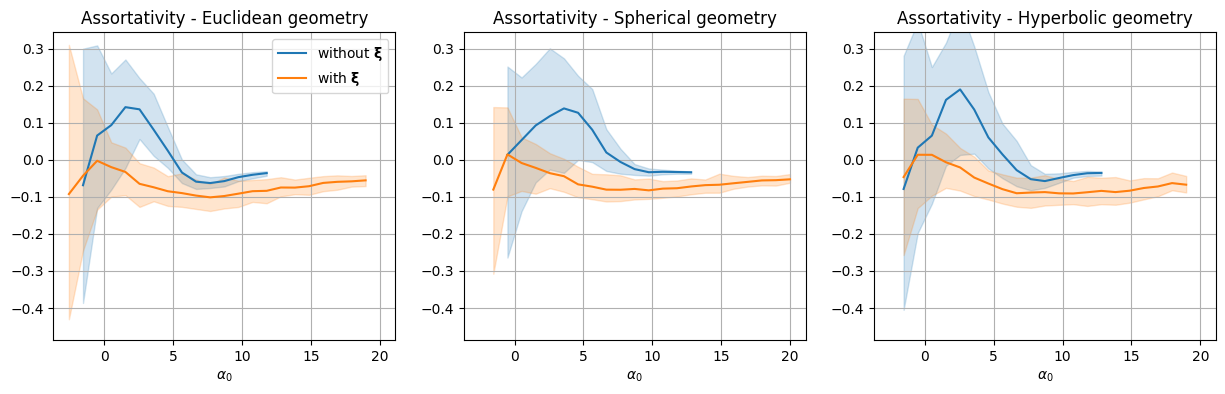

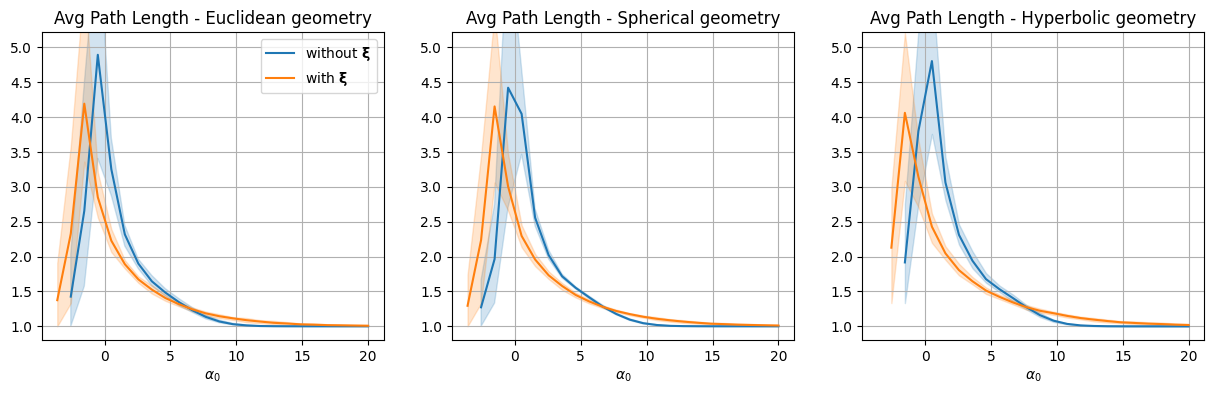

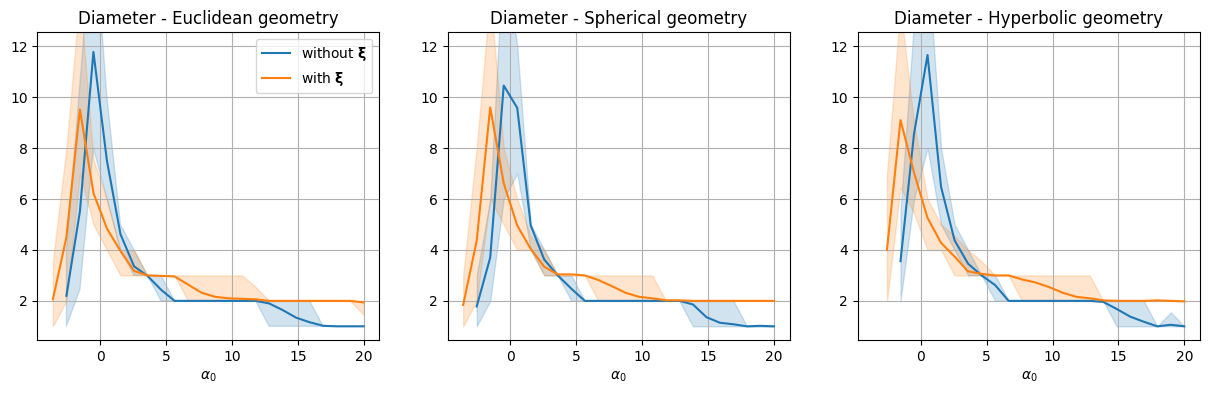

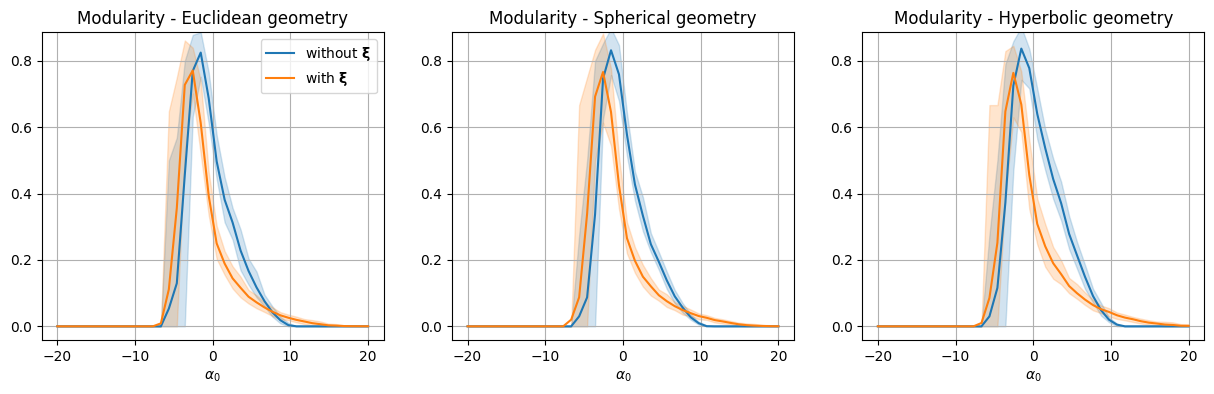

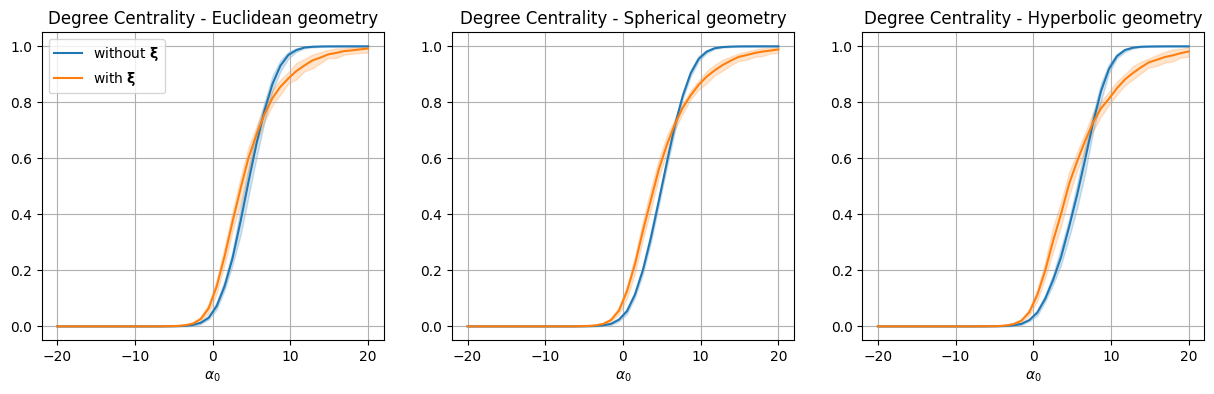

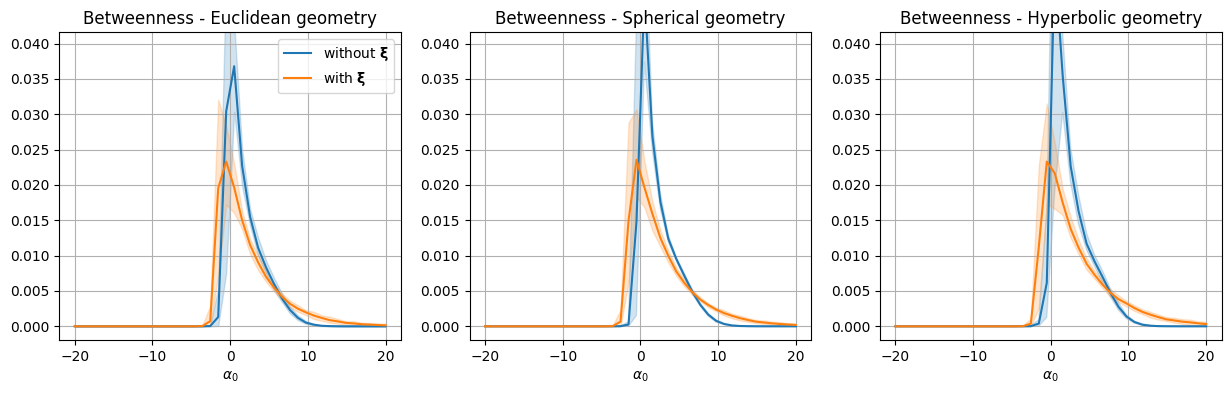

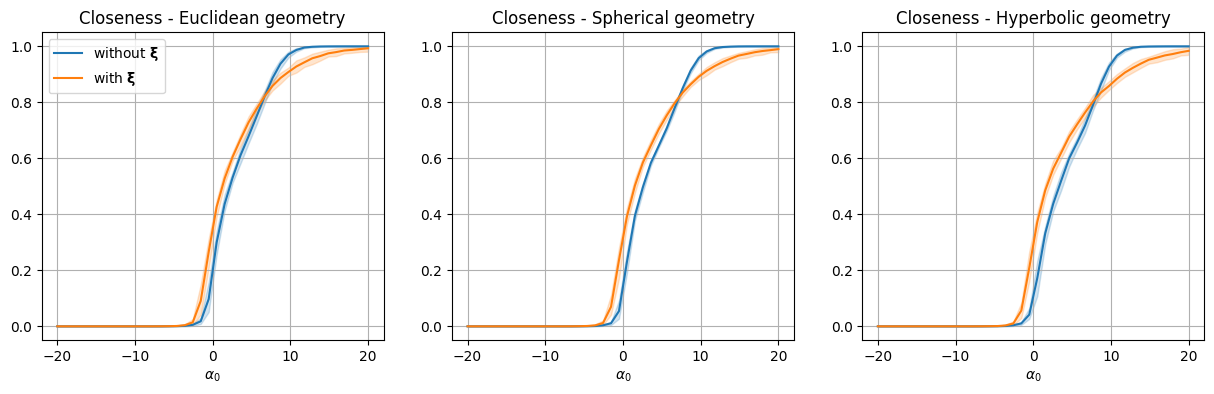

In [14]:

def plot_stat_comparison(alpha_grid, results_all, stat_key):

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

    geometries = ["euclidean", "spherical", "hyperbolic"]
    colors = {"no_xi": "tab:blue", "xi": "tab:orange"}
    all_values = []
    for geom in geometries:
        res_no_xi, res_xi = results_all[geom]

        data_no_xi = np.array(res_no_xi[stat_key])
        data_xi    = np.array(res_xi[stat_key])

        all_values.append(data_no_xi)
        all_values.append(data_xi)

    all_values = np.concatenate(all_values, axis=None)

    y_min = np.nanpercentile(all_values, 1)
    y_max = np.nanpercentile(all_values, 99)
    margin = 0.05 * (y_max - y_min)
    y_min -= margin
    y_max += margin
    for i, geom in enumerate(geometries):
        res_no_xi, res_xi = results_all[geom]
        data_no_xi = np.array(res_no_xi[stat_key])
        data_xi    = np.array(res_xi[stat_key])
        mean_no_xi = data_no_xi.mean(axis=1)
        mean_xi    = data_xi.mean(axis=1)

        low_no_xi = np.percentile(data_no_xi, 5, axis=1)
        high_no_xi = np.percentile(data_no_xi, 95, axis=1)

        low_xi = np.percentile(data_xi, 5, axis=1)
        high_xi = np.percentile(data_xi, 95, axis=1)
        ax = axes[i]

        # without xi
        ax.plot(alpha_grid, mean_no_xi, color=colors["no_xi"], label=r'without $\mathbf{\xi}$')
        ax.fill_between(alpha_grid, low_no_xi, high_no_xi, color=colors["no_xi"], alpha=0.2)

        # with xi
        ax.plot(alpha_grid, mean_xi, color=colors["xi"], label=r'with $\mathbf{\xi}$')
        ax.fill_between(alpha_grid, low_xi, high_xi, color=colors["xi"], alpha=0.2)

        ax.set_title(f"{stat_key.replace('_', ' ').title()} - {geom.capitalize()} geometry")
        ax.set_ylim(y_min, y_max)
        ax.grid(True)
        ax.set_xlabel(r'$\alpha_0$')
    axes[0].legend()
    plt.show()
for stat in stat_names:
    plot_stat_comparison(alpha_grid, results_all, stat)

## Experiment 6

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.special import expit

# =========================
# Laplacian spectrum
# =========================
def laplacian_spectrum(A):
    G = nx.from_numpy_array(A)
    L = nx.normalized_laplacian_matrix(G).toarray()
    eigvals = np.linalg.eigvalsh(L)
    return np.sort(eigvals)[::-1]  # descending


# =========================
# Simulate spectra
# =========================
def simulate_spectra(n, d, D, t, mu_alpha, alpha_std, c, geometry, seed=0):
    rng = np.random.default_rng(seed)

    spectra_no_xi = []
    spectra_xi = []

    for _ in range(t):

        # sample alpha0
        alpha0 = rng.normal(mu_alpha, alpha_std)

        # latent positions
        Z = sample_latent_positions(n, d, D, geometry, seed=rng.integers(1e9))

        # distances
        if geometry == "euclidean":
            Dmat = distance_matrix_euclidean(Z)
        elif geometry == "spherical":
            R = D / np.pi
            Dmat = distance_matrix_spherical(Z, R)
        elif geometry == "hyperbolic":
            R = D / np.pi
            Dmat = distance_matrix_hyperbolic(Z, R)

        # xi
        xi = n * rng.dirichlet(alpha=c * np.ones(n))
        Dmat_xi = apply_xi_matrix(Dmat, xi)

        # probabilities
        P0 = expit(alpha0 - Dmat)
        P1 = expit(alpha0 - Dmat_xi)

        # sample networks
        A0 = sample_network(P0, rng)
        A1 = sample_network(P1, rng)

        # spectra
        try:
            spectra_no_xi.append(laplacian_spectrum(A0))
            spectra_xi.append(laplacian_spectrum(A1))
        except:
            continue

    return np.array(spectra_no_xi), np.array(spectra_xi)

def plot_graph_and_spectra(
    G,
    d=2,
    D=10,
    t=50,
    mu_alpha=0,
    alpha_std=5,
    c=1,
    seed=0
):

    rng = np.random.default_rng(seed)

    n = G.number_of_nodes()
    A_obs = nx.to_numpy_array(G)
    spec_obs = laplacian_spectrum(A_obs)

    geometries = ["euclidean", "spherical", "hyperbolic"]

    colors = {
        "obs": "black",
        "no_xi": "#d62728",
        "xi": "#2ca02c"
    }
    spectra_dict = {}

    all_specs = []

    for geom in geometries:
        spec0, spec1 = simulate_spectra(
            n=n, d=d, D=D, t=t,
            mu_alpha=mu_alpha,
            alpha_std=alpha_std,
            c=c,
            geometry=geom,
            seed=seed
        )

        spec0 = np.array(spec0)
        spec1 = np.array(spec1)

        spectra_dict[geom] = (spec0, spec1)

        if len(spec0) > 0:
            all_specs.append(spec0)
        if len(spec1) > 0:
            all_specs.append(spec1)

    if len(all_specs) > 0:
        all_specs = np.concatenate(all_specs, axis=0)
        ymin = np.nanmin(all_specs)
        ymax = np.nanmax(all_specs)
    else:
        ymin, ymax = 0, 2

    # =========================
    # Plot
    # =========================
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # ---- Graph ----
    pos = nx.spring_layout(G, seed=seed)
    nx.draw(
        G, pos=pos,
        ax=axes[0],
        with_labels=True,
        node_color='lightblue',
        edge_color='gray',
        node_size=800,
        font_size=10
    )
    axes[0].set_title("Observed Network", fontsize=12, weight='bold')
    axes[0].axis('off')

    # =========================
    # Spectral plots
    # =========================
    for i, geom in enumerate(geometries):

        ax = axes[i+1]
        spec0, spec1 = spectra_dict[geom]

        if len(spec0) == 0 or len(spec1) == 0:
            continue

        # ---- means ----
        mean0 = np.nanmean(spec0, axis=0)
        mean1 = np.nanmean(spec1, axis=0)

        # ---- bands ----
        low0 = np.nanpercentile(spec0, 5, axis=0)
        high0 = np.nanpercentile(spec0, 95, axis=0)

        low1 = np.nanpercentile(spec1, 5, axis=0)
        high1 = np.nanpercentile(spec1, 95, axis=0)

        x = np.arange(len(mean0))

        # ---- plot bands ----
        ax.fill_between(x, low0, high0, color=colors["no_xi"], alpha=0.2)
        ax.fill_between(x, low1, high1, color=colors["xi"], alpha=0.2)

        # ---- plot means ----
        ax.plot(x, mean0, color=colors["no_xi"], linewidth=2.5, label="Without ξ")
        ax.plot(x, mean1, color=colors["xi"], linewidth=2.5, label="With ξ")

        # ---- observed ----
        ax.plot(x, spec_obs, color=colors["obs"], linewidth=3, label="Observed")

        # ---- distances (fit quality) ----
        dist0 = np.linalg.norm(mean0 - spec_obs)
        dist1 = np.linalg.norm(mean1 - spec_obs)

        ax.text(0.02, 0.12, f"d(no ξ)={dist0:.2f}", transform=ax.transAxes, color=colors["no_xi"], fontsize=11)
        ax.text(0.02, 0.04, f"d(ξ)={dist1:.2f}", transform=ax.transAxes, color=colors["xi"], fontsize=11)

        # ---- style ----
        ax.set_title(f"{geom.capitalize()} Geometry", fontsize=12, weight='bold')
        ax.set_xlabel("Order")
        ax.set_ylabel("Eigenvalue")

        ax.set_ylim(ymin, np.max(np.array([ymax, spec_obs.max() + 0.05])))

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(alpha=0.2)

    # =========================
    # Legend (clean)
    # =========================
    axes[1].legend(loc="upper right", frameon=False)

    plt.tight_layout()
    plt.show()

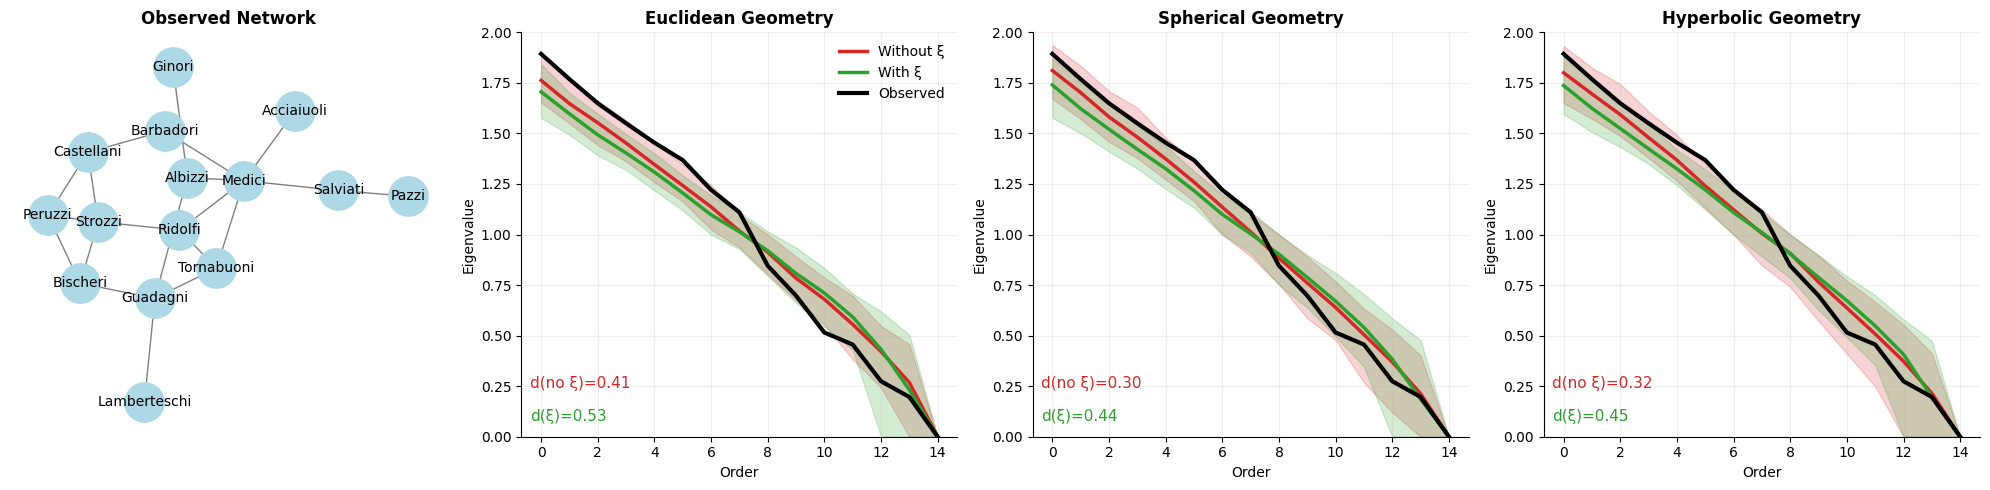

In [16]:
G = nx.florentine_families_graph()
plot_graph_and_spectra(G, d=2, D=3.1416, t=100, mu_alpha=0.30, alpha_std=0.1, c=0.80, seed=42)

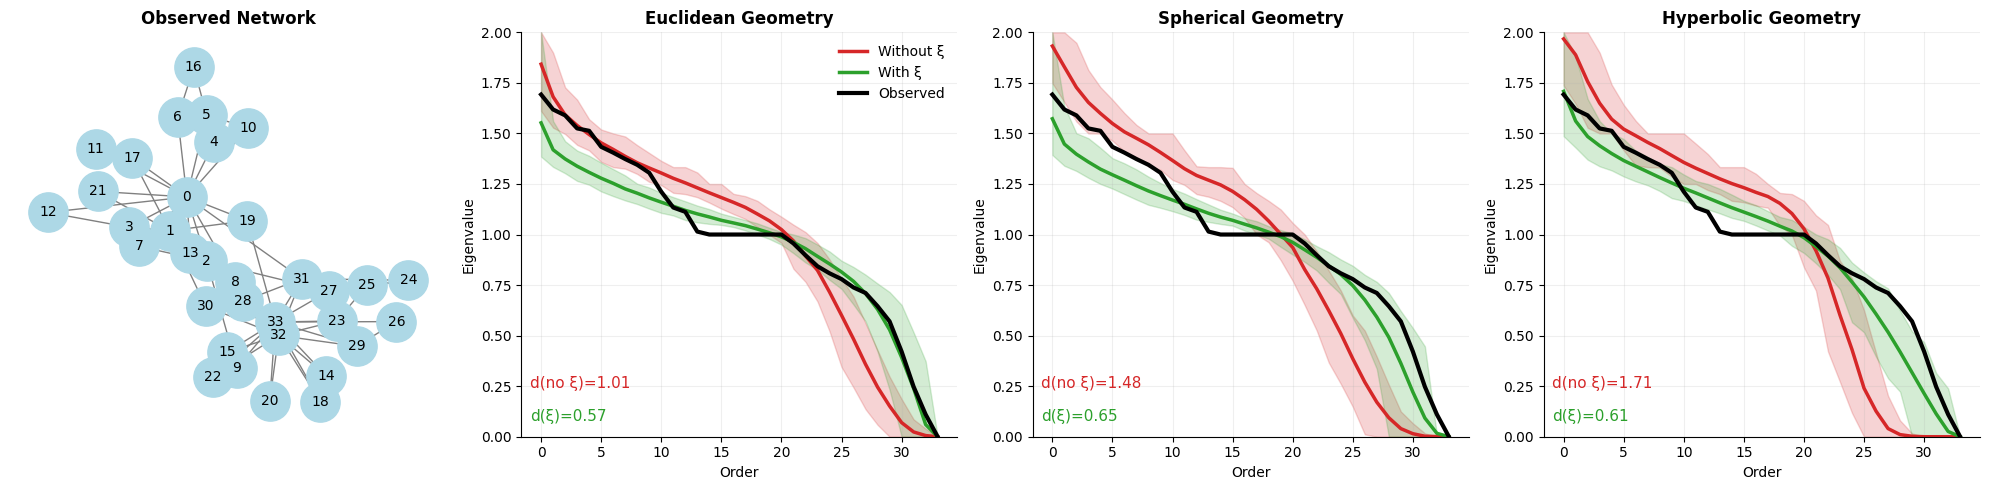

In [17]:
G = nx.karate_club_graph()
plot_graph_and_spectra(G, d=2, D=100, t=100, mu_alpha=20.0, alpha_std=1.0, c=1.0, seed=42)

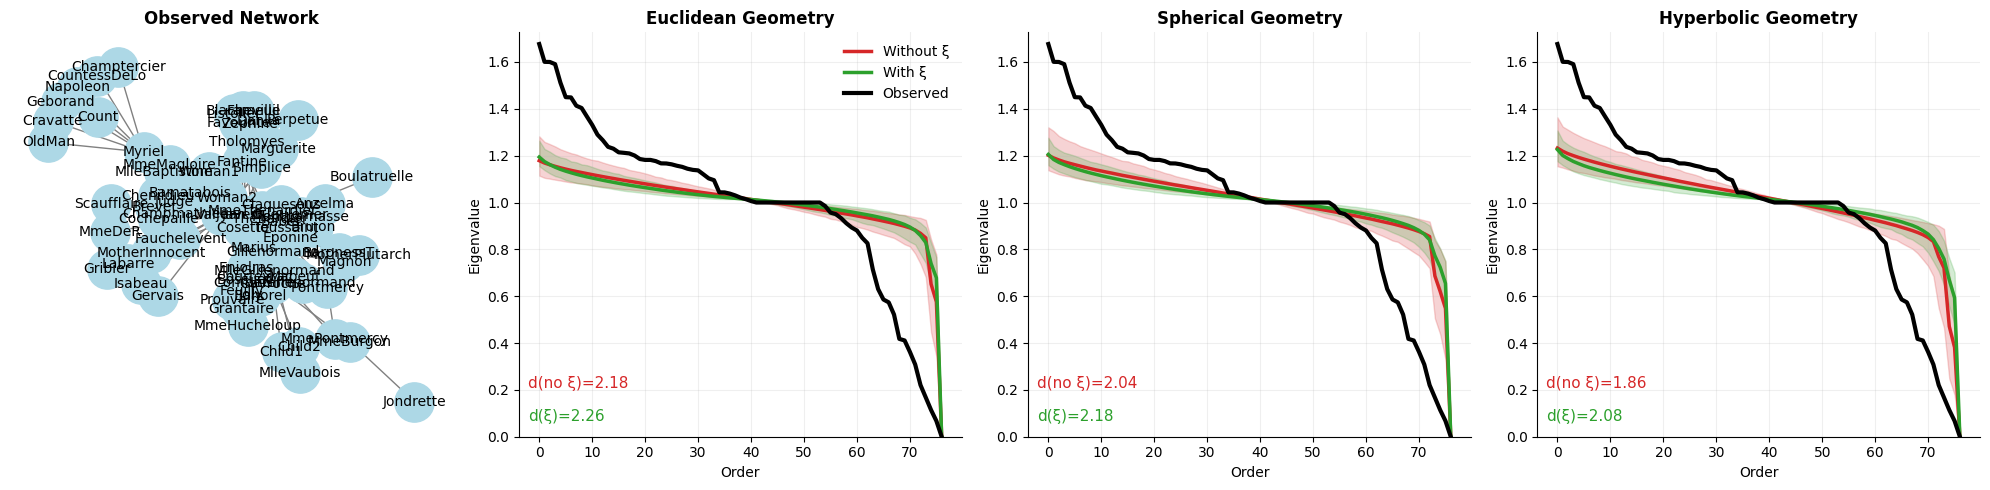

In [18]:
G = nx.les_miserables_graph()
plot_graph_and_spectra(G, d=2, D=10, t=250, mu_alpha=5.0, alpha_std=1.0, c=1.0, seed=42)

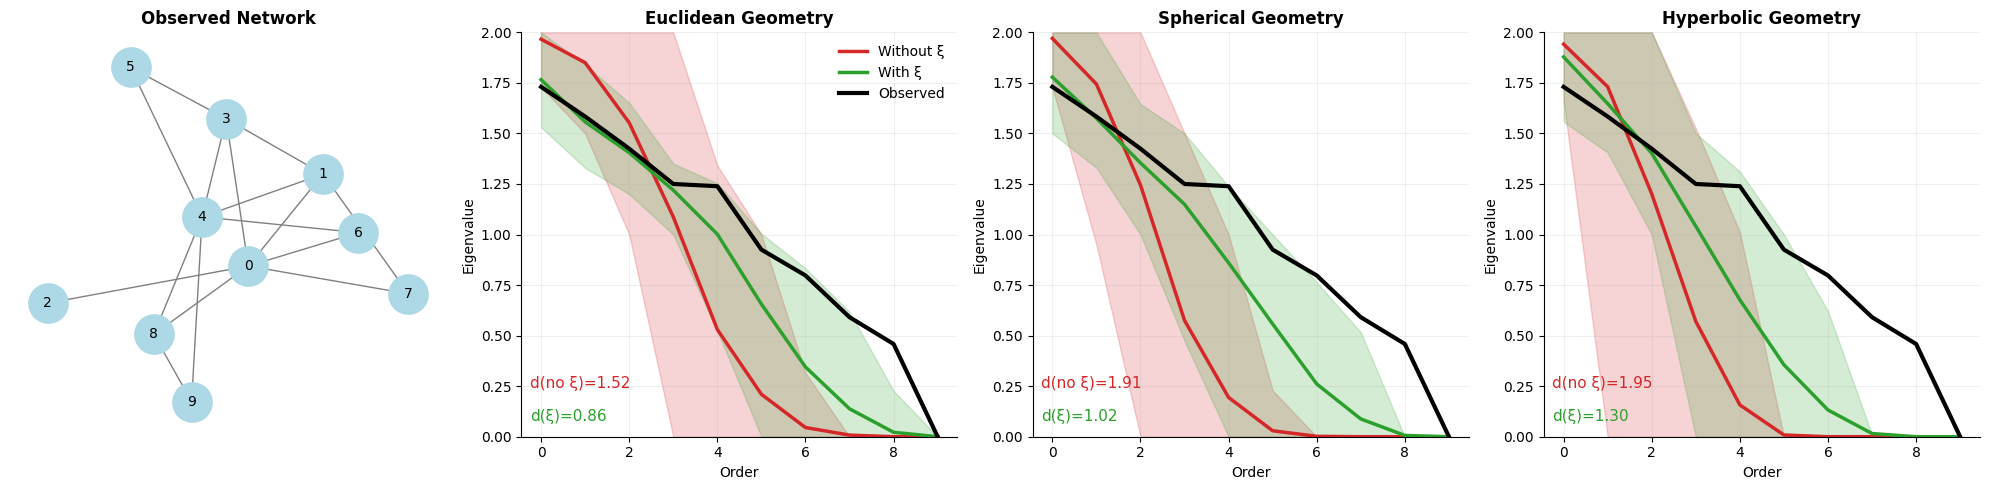

In [19]:
G = nx.barabasi_albert_graph(10, 2)
plot_graph_and_spectra(G, d=2, D=100, t=100, mu_alpha=20.0, alpha_std=1.0, c=1.0, seed=42)

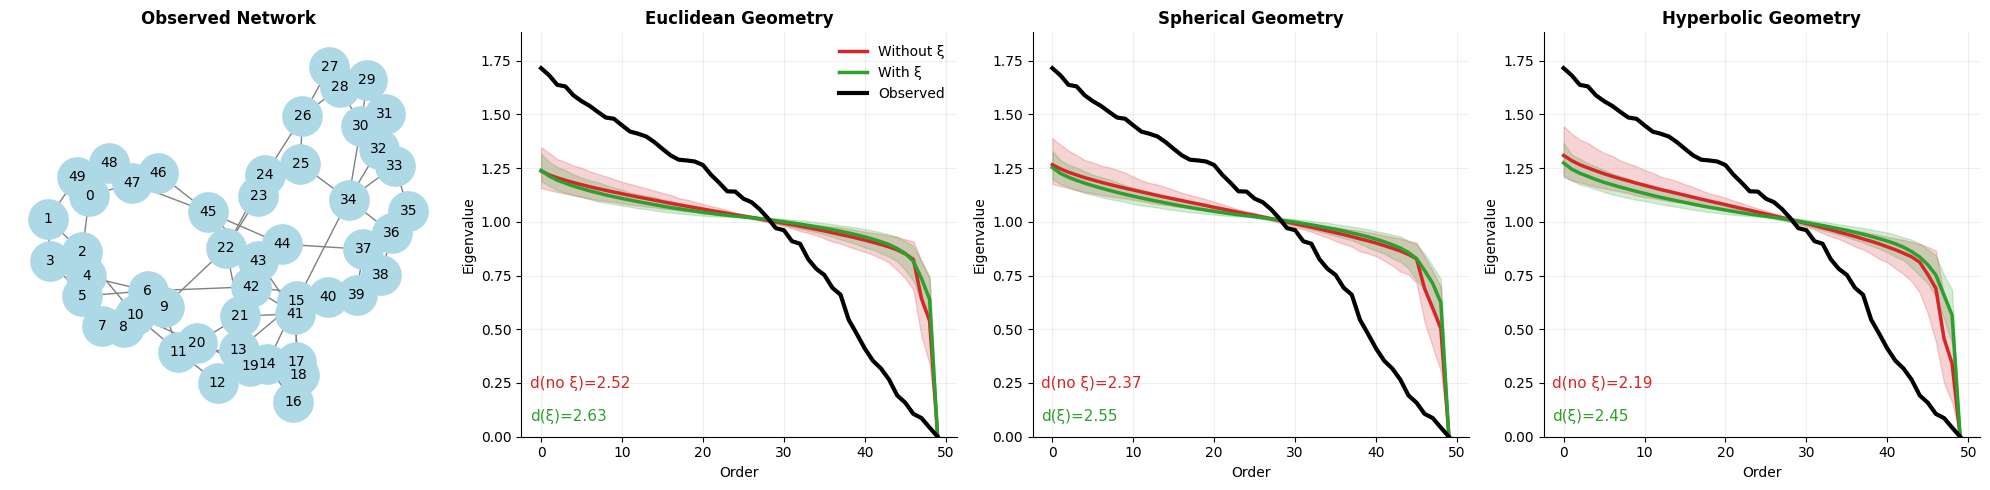

In [20]:
G = nx.watts_strogatz_graph(50, k=4, p=0.1)
plot_graph_and_spectra(G, d=2, D=10, t=250, mu_alpha=5.0, alpha_std=1.0, c=1.0, seed=42)

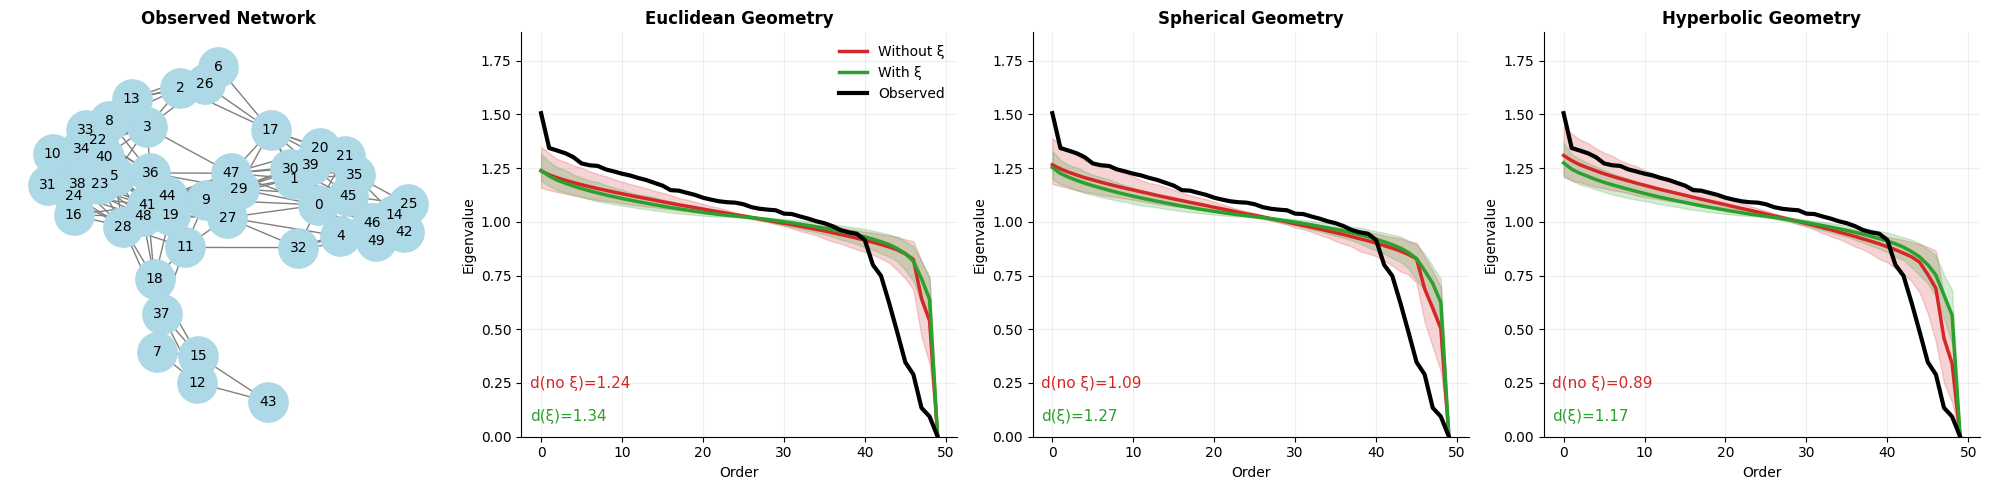

In [21]:
G = nx.random_geometric_graph(50, radius=0.3)
plot_graph_and_spectra(G, d=2, D=10, t=250, mu_alpha=5.0, alpha_std=1.0, c=1.0, seed=42)

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit

def spectral_heatmap_alpha0(
    n,
    d,
    D,
    alpha_grid,
    t,
    geometry="euclidean",
    c=1,
    with_xi=False,
    seed=0
):
   
    rng = np.random.default_rng(seed)

    mean_spectra = []

    for alpha0 in alpha_grid:

        spectra_alpha = []

        for _ in range(t):

            # ---- sample latent positions ----
            Z = sample_latent_positions(
                n, d, D, geometry,
                seed=rng.integers(1e9)
            )

            # ---- distances ----
            if geometry == "euclidean":
                Dmat = distance_matrix_euclidean(Z)
            elif geometry == "spherical":
                R = D / np.pi
                Dmat = distance_matrix_spherical(Z, R)
            elif geometry == "hyperbolic":
                R = D / np.pi
                Dmat = distance_matrix_hyperbolic(Z, R)

            # ---- xi (optional) ----
            if with_xi:
                xi = n * rng.dirichlet(alpha=c * np.ones(n))
                Dmat = apply_xi_matrix(Dmat, xi)

            # ---- probabilities ----
            P = expit(alpha0 - Dmat)

            # ---- sample graph ----
            A = sample_network(P, rng)

            try:
                eigs = laplacian_spectrum(A)
                spectra_alpha.append(eigs)
            except:
                continue

        spectra_alpha = np.array(spectra_alpha)
        mean_spec = np.mean(spectra_alpha, axis=0)
        mean_spectra.append(mean_spec)
    return np.array(mean_spectra)

def plot_spectral_heatmap(mean_spectra, alpha_grid,cmap="gray"):
    M = mean_spectra.T 

    n_eigs = M.shape[0]

    plt.figure(figsize=(8, 6))

    plt.imshow(
        M,
        aspect='auto',
        origin='lower',
        extent=[alpha_grid[0], alpha_grid[-1], 1, n_eigs],
        cmap=cmap,
        vmin=0,
        vmax=2
    )

    plt.colorbar(label="Mean eigenvalue")
    plt.xlabel(r"$\alpha_0$")
    plt.ylabel("Eigenvalue index (k)")
    step = max(1, n_eigs // 20)
    plt.yticks(np.arange(1, n_eigs+1, step))

    plt.show()

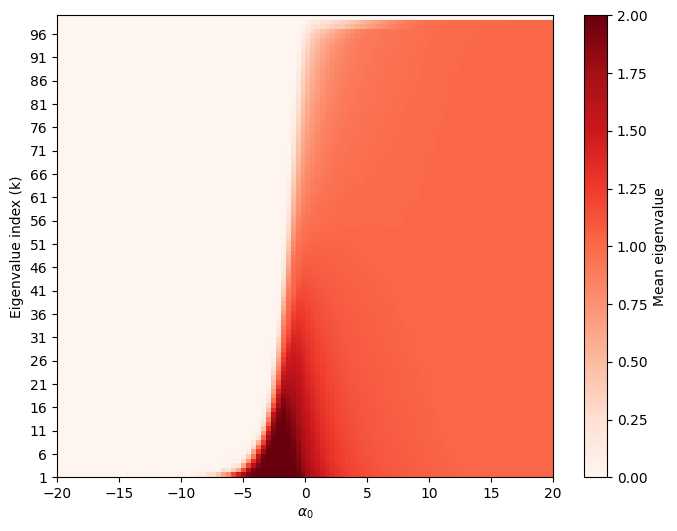

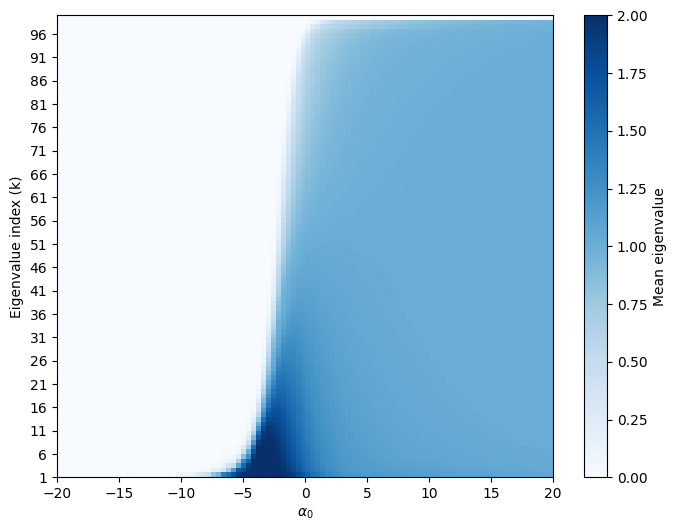

In [101]:
alpha_grid = np.linspace(-20, 20, 100)
mean_no_xi = spectral_heatmap_alpha0(n=100, d=2, D=10, alpha_grid=alpha_grid, t=100, geometry="euclidean", with_xi=False)
plot_spectral_heatmap(mean_no_xi, alpha_grid, cmap="Reds")
mean_xi = spectral_heatmap_alpha0(n=100, d=2, D=10, alpha_grid=alpha_grid, t=100, geometry="euclidean", with_xi=True)
plot_spectral_heatmap(mean_xi, alpha_grid, cmap="Blues")

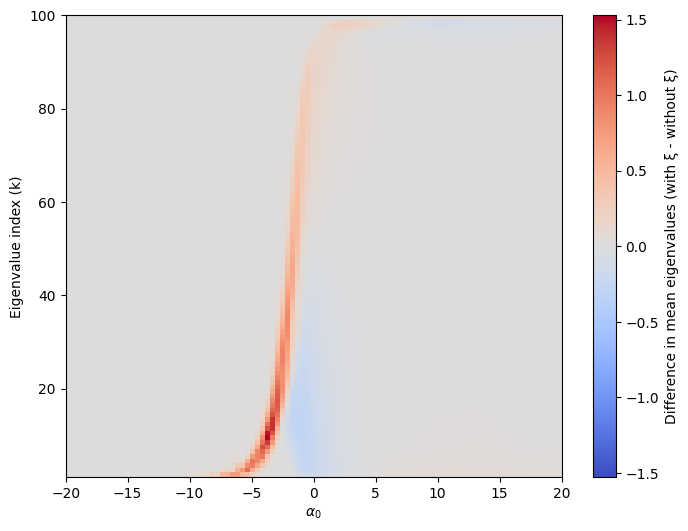

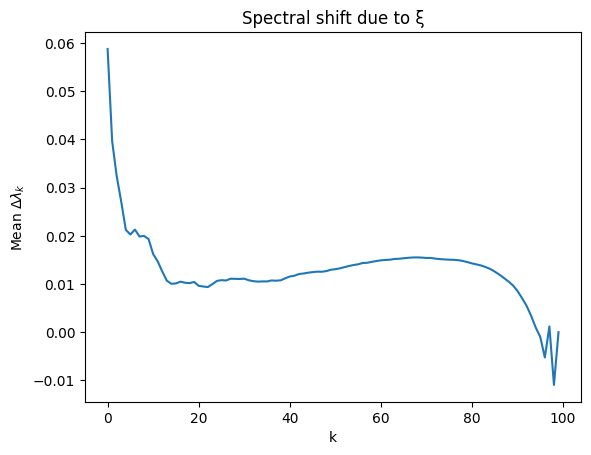

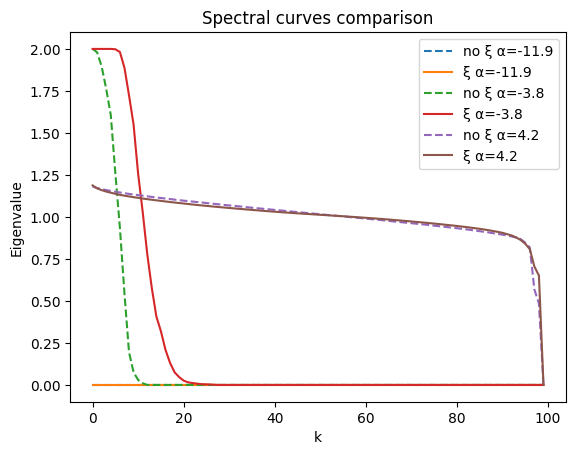

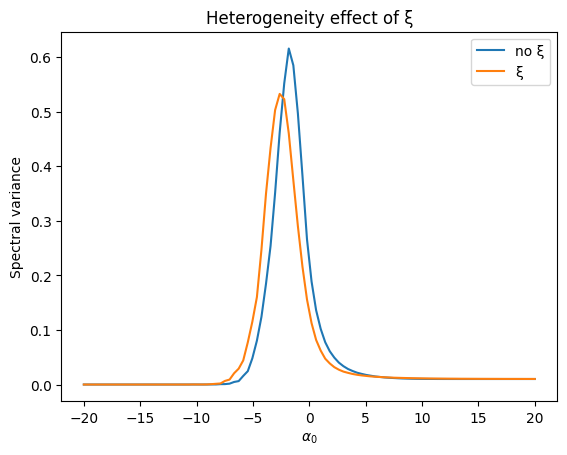

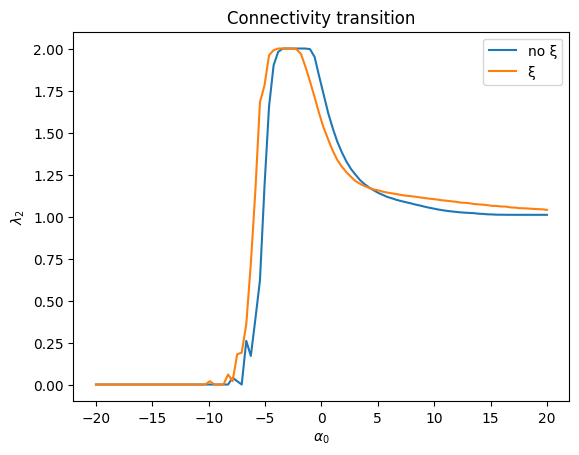

In [102]:
def plot_difference_heatmap(mean_no_xi, mean_xi, alpha_grid):
    M = (mean_xi - mean_no_xi).T  # (k, alpha)
    plt.figure(figsize=(8,6))
    vmax = np.max(np.abs(M))
    plt.imshow(
        M,
        aspect='auto',
        origin='lower',
        extent=[alpha_grid[0], alpha_grid[-1], 1, M.shape[0]],
        cmap="coolwarm",
        vmin=-vmax,
        vmax=vmax
    )
    plt.colorbar(label=r"Difference in mean eigenvalues (with ξ - without ξ)")
    plt.xlabel(r"$\alpha_0$")
    plt.ylabel("Eigenvalue index (k)")
    plt.title("")
    plt.show()

plot_difference_heatmap(mean_no_xi, mean_xi, alpha_grid)

delta = mean_xi - mean_no_xi
profile = delta.mean(axis=0)

plt.plot(profile)
plt.xlabel("k")
plt.ylabel(r"Mean $\Delta \lambda_k$")
plt.title("Spectral shift due to ξ")
plt.show()


idx = [20, 40, 60]  # ejemplos

for i in idx:
    plt.plot(mean_no_xi[i], label=f"no ξ α={alpha_grid[i]:.1f}", linestyle='--')
    plt.plot(mean_xi[i], label=f"ξ α={alpha_grid[i]:.1f}")

plt.legend()
plt.xlabel("k")
plt.ylabel("Eigenvalue")
plt.title("Spectral curves comparison")
plt.show()

var_no_xi = np.var(mean_no_xi, axis=1)
var_xi = np.var(mean_xi, axis=1)

plt.plot(alpha_grid, var_no_xi, label="no ξ")
plt.plot(alpha_grid, var_xi, label="ξ")

plt.legend()
plt.xlabel(r"$\alpha_0$")
plt.ylabel("Spectral variance")
plt.title("Heterogeneity effect of ξ")
plt.show()


plt.plot(alpha_grid, mean_no_xi[:,1], label="no ξ")
plt.plot(alpha_grid, mean_xi[:,1], label="ξ")

plt.legend()
plt.xlabel(r"$\alpha_0$")
plt.ylabel(r"$\lambda_2$")
plt.title("Connectivity transition")
plt.show()

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit

def plot_spectra_grid_3x3(
    alpha_list,
    n=50,
    d=2,
    D=10,
    t=100,
    c=1,
    seed=0
):

    rng = np.random.default_rng(seed)

    geometries = ["euclidean", "spherical", "hyperbolic"]

    fig, axes = plt.subplots(3, 3, figsize=(15, 12))

    for i, alpha0 in enumerate(alpha_list):
        for j, geom in enumerate(geometries):

            spectra_no_xi = []
            spectra_xi = []

            for _ in range(t):

                # ---- sample latent positions ----
                Z = sample_latent_positions(
                    n, d, D, geom,
                    seed=rng.integers(1e9)
                )

                # ---- distances ----
                if geom == "euclidean":
                    Dmat = distance_matrix_euclidean(Z)
                elif geom == "spherical":
                    R = D / np.pi
                    Dmat = distance_matrix_spherical(Z, R)
                elif geom == "hyperbolic":
                    R = D / np.pi
                    Dmat = distance_matrix_hyperbolic(Z, R)

                # ---- xi ----
                xi = n * rng.dirichlet(alpha=c * np.ones(n))
                Dmat_xi = apply_xi_matrix(Dmat, xi)

                # ---- probabilities ----
                P0 = expit(alpha0 - Dmat)
                P1 = expit(alpha0 - Dmat_xi)

                # ---- sample networks ----
                A0 = sample_network(P0, rng)
                A1 = sample_network(P1, rng)

                try:
                    spectra_no_xi.append(laplacian_spectrum(A0))
                    spectra_xi.append(laplacian_spectrum(A1))
                except:
                    continue

            spectra_no_xi = np.array(spectra_no_xi)
            spectra_xi = np.array(spectra_xi)

            ax = axes[i, j]

            if len(spectra_no_xi) == 0 or len(spectra_xi) == 0:
                continue

            # ---- stats ----
            mean0 = np.mean(spectra_no_xi, axis=0)
            low0 = np.percentile(spectra_no_xi, 1, axis=0)
            high0 = np.percentile(spectra_no_xi, 99, axis=0)

            mean1 = np.mean(spectra_xi, axis=0)
            low1 = np.percentile(spectra_xi, 1, axis=0)
            high1 = np.percentile(spectra_xi, 99, axis=0)

            k = np.arange(len(mean0))

            # ---- plot ----
            ax.fill_between(k, low0, high0, color="red", alpha=0.2)
            ax.plot(k, mean0, color="red", linewidth=2)

            ax.fill_between(k, low1, high1, color="blue", alpha=0.2)
            ax.plot(k, mean1, color="blue", linewidth=2)

            # ---- titles ----
            if i == 0:
                ax.set_title(geom.capitalize(), fontsize=12, weight='bold')
            

            ax.set_ylim(0, 2)
            ax.grid(alpha=0.2)
            line_no_xi = ax.plot(k, mean0, color="red", linewidth=2)[0]
            line_xi    = ax.plot(k, mean1, color="blue", linewidth=2)[0]
            step = max(1, len(mean0)//10)
            ax.set_xticks(np.arange(0, len(mean0)+1, step))

    fig.text(
                0.04, 0.5,
                "Graph Laplacian Spectrum",
                va='center',
                rotation='vertical',
                fontsize=14
            )
    for i, alpha0 in enumerate(alpha_list):
        fig.text(
            0.98,                      
            0.83 - i*0.32,           
            f"$\\alpha_0 = {alpha0}$",
            va='center',
            ha='right',
            fontsize=10
        )
    # ---- single legend ----
    axes[0,0].legend(
        [line_no_xi, line_xi],
        ["Without ξ", "With ξ"],
        loc="upper right",
        frameon=False
    )
    # ---- shared labels ----
    for ax in axes[-1, :]:
        ax.set_xlabel("Eigenvalue index (k)")
    plt.tight_layout(rect=[0.06, 0, 0.95, 1])
    plt.show()


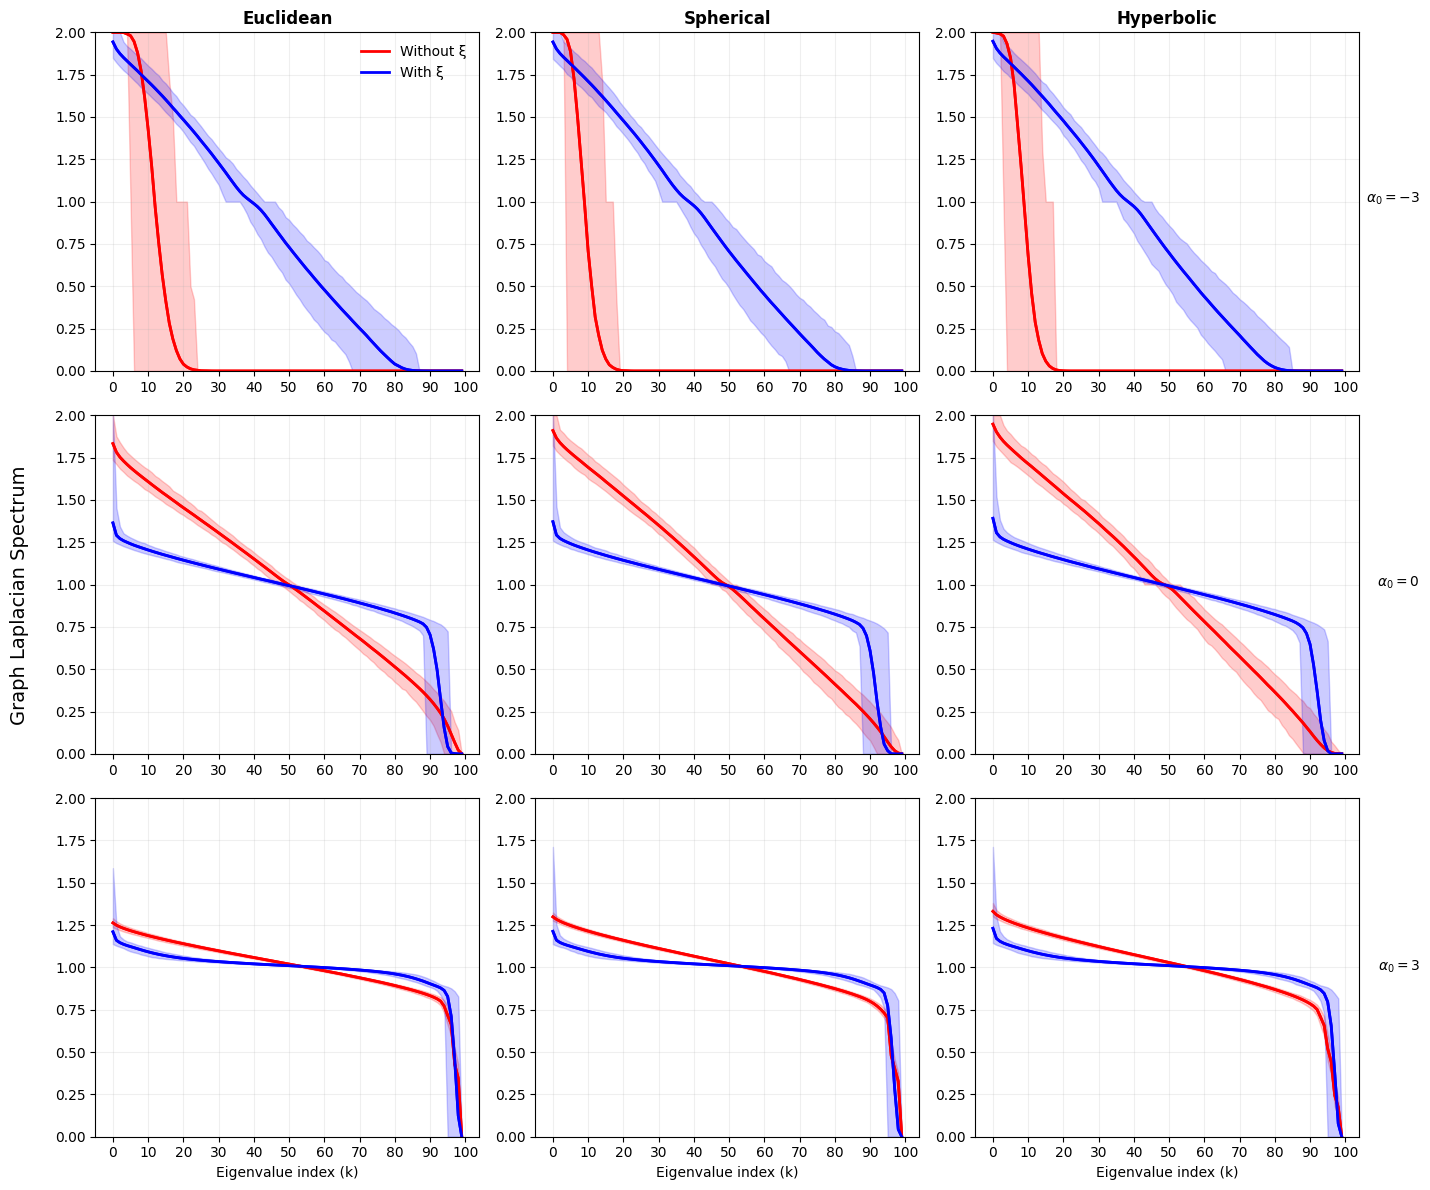

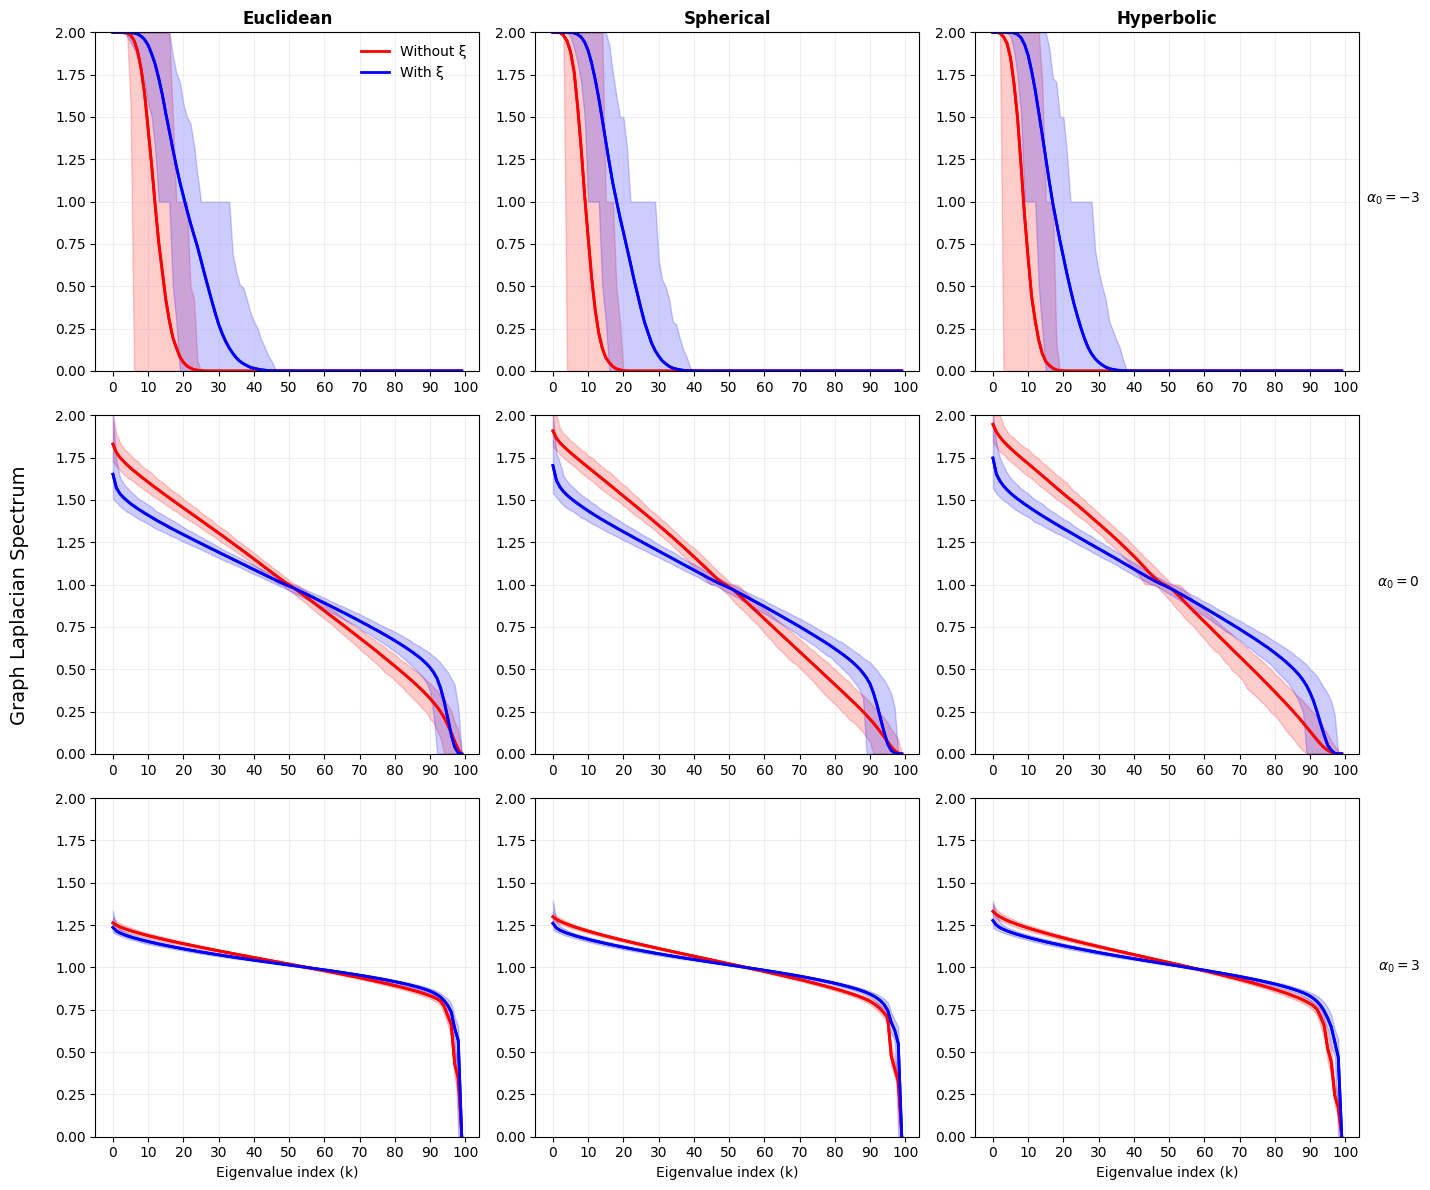

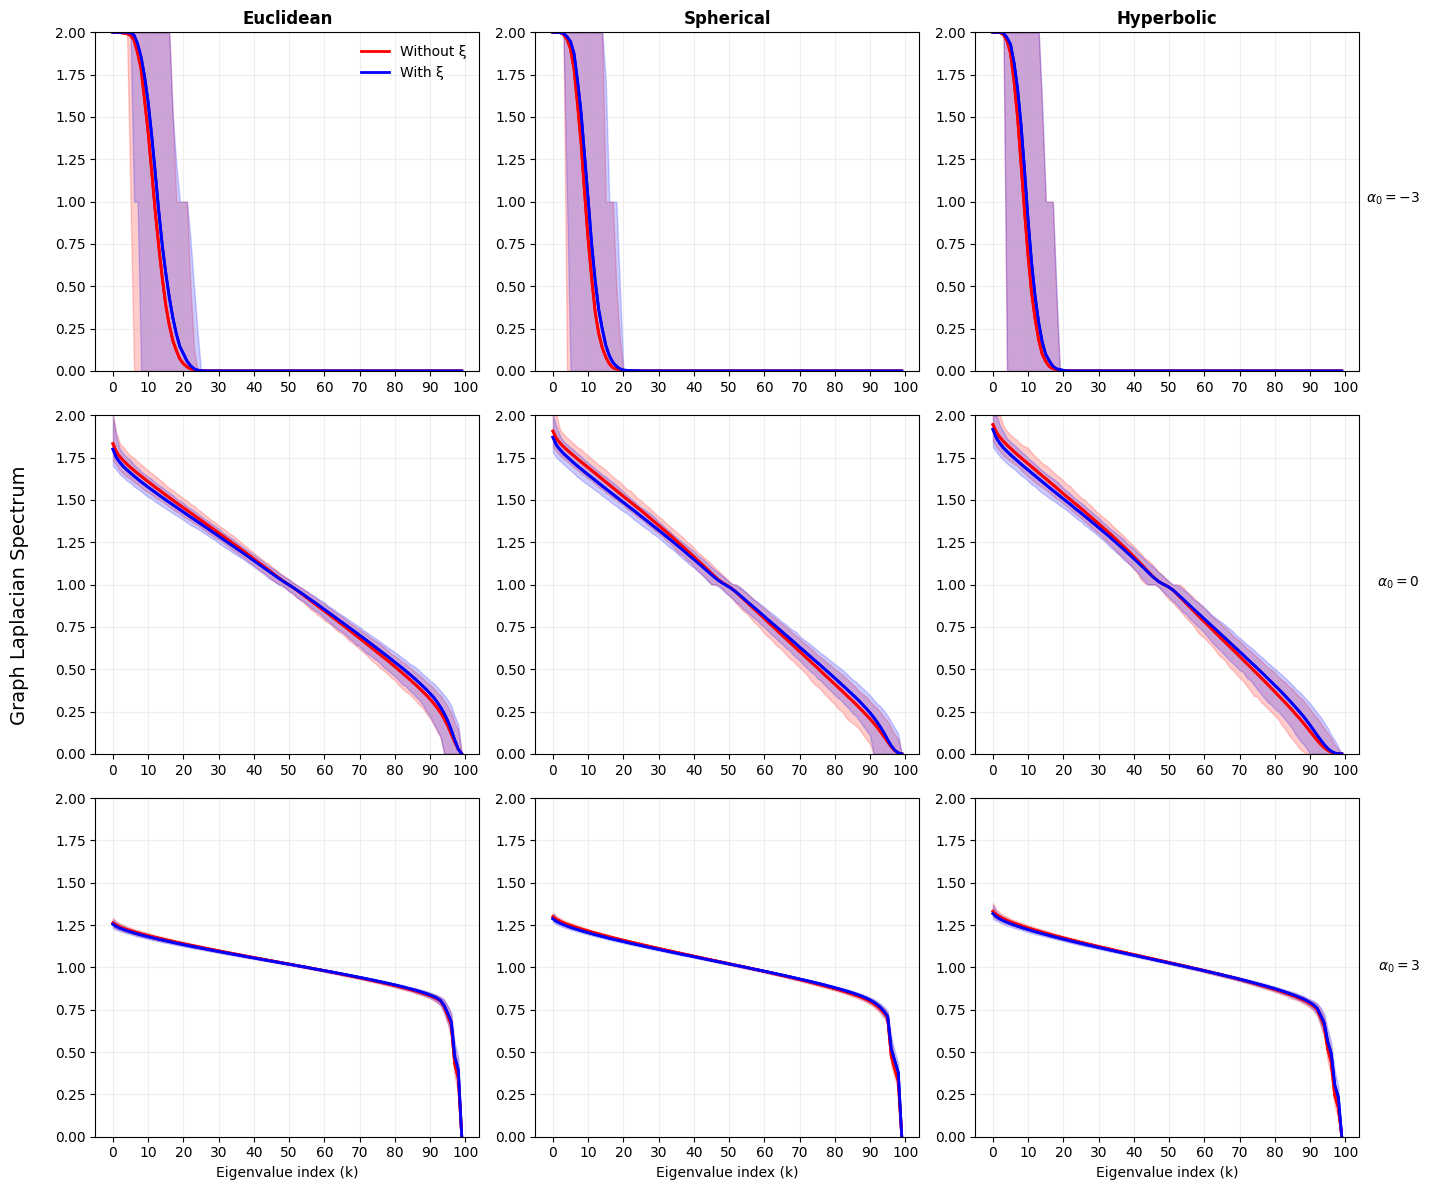

In [104]:
plot_spectra_grid_3x3( alpha_list=[-3, 0, 3], n=100, d=2, D=10, t=1000, c=0.1)
plot_spectra_grid_3x3( alpha_list=[-3, 0, 3], n=100, d=2, D=10, t=1000, c=1.0)
plot_spectra_grid_3x3( alpha_list=[-3, 0, 3], n=100, d=2, D=10, t=1000, c=10.0)